# OncoBridge-MMCAT **v8** — 4-Modality Pan-Cancer Classifier with SHAP & Cancer-Gene Atlas

> Successor to v7 (95.74% on 22-class, 91.24% on 32-class).
> Targets: **>96% on 22-class**, **>93% test + macro-F1 ≥0.88 on 32-class**.

---

### What's new in v8 (improvements over v7)

| # | Improvement | Type | Where |
|---|-------------|------|-------|
| 1 | **DropPath / Stochastic Depth** in the transformer encoders | Architecture | `ModalityEncoder` |
| 2 | **Modality-type token embeddings** (4 learnable vectors, one per omic) | Architecture | added to all tokens before encoder |
| 3 | **Fusion Transformer** (2-layer self-attn over the 4 CLS tokens) | Architecture | replaces single-layer GatedFusion |
| 4 | **Auxiliary modality classifiers** (deep supervision, weight=0.1) | Training | per-modality CLS → CE |
| 5 | **EMA of weights** (α=0.999) | Training | parallel shadow model |
| 6 | **Snapshot averaging** (mean of top-3 checkpoints by val acc) | Training | end-of-training |
| 7 | **Test-Time Augmentation** (5 forward passes with mRNA Gaussian noise σ=0.02) | Inference | `tta_predict()` |
| 8 | **WeightedRandomSampler** (configurable, default ON for ALL_CLASSES) | Training | per-sample inverse frequency |
| 9 | **SHAP cell** (GradientSHAP on test set, per-gene importance per cancer) | Interpretability | new cell |
| 10 | **Cancer-Gene 2D Atlas** (UMAP of cancer centroids + genes placed by SHAP weight) | Interpretability | new cell |
| 11 | **Full checkpoint** (model + EMA + scalers + gene indices + label encoder) — fully reproducible loading | Engineering | `save_full_checkpoint()` |

### Two run modes
1. **Run-all from scratch** — trains, evaluates, runs SHAP, then atlas. Just press *Run All*.
2. **Load pretrained + analysis only** — set `LOAD_PRETRAINED = True` in Cell 2. The notebook will skip training, restore everything from the saved `.pt` file (model weights, scalers, gene indices, label encoder), and you can run only the SHAP/atlas cells. **You still need to run cells 1–7 once** (config, imports, data load, splits/scalers — they're fast and re-create context). Then jump to the eval/SHAP/atlas cells.

> ⚠ **Hardware:** Designed for Kaggle T4×2 (15.6 GB each) + 30 GB RAM. AMP + grad checkpointing + grad accumulation keep peak GPU at ~2 GB and peak RAM at ~12 GB.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════════
import os, gc, copy, time, math, json, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    matthews_corrcoef, confusion_matrix, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold

# Plot defaults
plt.rcParams['figure.dpi']        = 110
plt.rcParams['font.size']         = 10
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

# Pretty section divider
def section(title, char='=', width=80):
    print('\n' + char * width)
    print(f'  {title}')
    print(char * width)

# Pretty timer
class Timer:
    def __init__(self, name=''): self.name = name
    def __enter__(self):  self.t0 = time.time(); return self
    def __exit__(self, *a):
        dt = time.time() - self.t0
        if self.name: print(f'  >> {self.name}: {dt:.1f}s')

print('Imports OK.')
print(f'  torch:        {torch.__version__}')
print(f'  numpy:        {np.__version__}')
print(f'  pandas:       {pd.__version__}')
print(f'  CUDA available: {torch.cuda.is_available()}')

Imports OK.
  torch:        2.10.0+cu128
  numpy:        2.0.2
  pandas:       2.3.3
  CUDA available: True


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 2 — Master CONFIG
#  All knobs live in one place. Change here, never inside the body cells.
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Data paths ────────────────────────────────────────────────────────
    'mrna_path'  : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data-muationmrnacnvmethyl-idgene/mrna_final.parquet',
    'cnv_path'   : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data-muationmrnacnvmethyl-idgene/cnv_final.parquet',
    'mut_path'   : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data-muationmrnacnvmethyl-idgene/mut_final.parquet',
    'meth_path'  : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data-muationmrnacnvmethyl-idgene/meth_final.parquet',
    'label_path' : '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data-muationmrnacnvmethyl-idgene/labels_final.parquet',

    # ── Mode flags ────────────────────────────────────────────────────────
    # If True: skip training, load weights + scalers + indices from CHECKPOINT_PATH
    # If False: train from scratch
    'LOAD_PRETRAINED'    : False,
    # Path to load from / save to.
    'CHECKPOINT_PATH'    : '/kaggle/working/oncobridge_v8_full.pt',
    # Toggles for the analysis cells (set False to skip)
    'RUN_SHAP'           : False,
    'RUN_ATLAS'          : False,
    'SHAP_PER_CLASS'     : 8,         # # test samples per class to attribute
    'SHAP_BG_SIZE'       : 64,        # background reference set size

    # ── Class filter ──────────────────────────────────────────────────────
    # True  → drop classes with < min_samples_per_class (the 22-class run)
    # False → keep ALL 32 classes
    'balanced_classes_only': True,
    'min_samples_per_class': 100,

    # ── Gene selection ────────────────────────────────────────────────────
    'auto_k_coverage': 0.88,
    'mrna_max_k'     : 9000,
    'cnv_max_k'      : 3500,
    'mut_max_k'      : 2500,
    'meth_max_k'     : 6000,

    # ── Architecture (v8 = v7 + improvements; keep v7 proven values) ──────
    'embed_dim'         : 384,
    'num_heads'         : 8,
    'num_encoder_layers': 6,
    'num_cross_layers'  : 4,
    'cnn_kernel'        : 16,
    'cnn_stride'        : 16,
    'ff_dim'            : 1536,
    'dropout'           : 0.20,

    # NEW v8: stochastic depth (DropPath). Linearly scaled across encoder layers.
    # 0.10 => layer 1 has p=0, last encoder layer has p=0.10
    'drop_path_max'     : 0.10,
    # NEW v8: modality-type token embedding
    'use_modality_embed': True,
    # NEW v8: fusion transformer over the 4 CLS tokens (set 0 to disable)
    'fusion_layers'     : 2,
    # NEW v8: auxiliary deep supervision on per-modality CLS
    'aux_loss_weight'   : 0.10,

    # T-GEM-inspired gene importance gating
    'gate_init'         : 1.5,

    # ── Training ──────────────────────────────────────────────────────────
    'epochs'         : 140,
    'batch_size'     : 64,
    'grad_accum'     : 8,        # effective batch = 512
    'lr'             : 2e-4,
    'weight_decay'   : 3e-4,
    'patience'       : 22,       # slightly more than v7 — EMA needs runway
    'label_smoothing': 0.05,
    'clip_grad'      : 1.0,
    'warmup_frac'    : 0.15,
    'num_workers'    : 2,
    'use_amp'        : True,
    'use_grad_ckpt'  : False,

    # ── Loss & sampling ───────────────────────────────────────────────────
    'max_class_weight': 8.0,
    # NEW v8: WeightedRandomSampler. Crucial for 32-class; harmless for 22.
    'use_weighted_sampler': True,

    # ── Mixup (kept from v3 proven) ───────────────────────────────────────
    'use_mixup'  : True,
    'mixup_prob' : 0.50,
    'mixup_alpha': 0.2,

    # ── EMA (NEW v8) ──────────────────────────────────────────────────────
    'use_ema'    : True,
    'ema_decay'  : 0.999,
    'ema_warmup_steps': 100,

    # ── Snapshot averaging (NEW v8) ───────────────────────────────────────
    'snapshot_top_k': 3,

    # ── TTA (NEW v8) ──────────────────────────────────────────────────────
    'use_tta'      : True,
    'tta_n_passes' : 5,
    'tta_mrna_noise_std': 0.02,
    'tta_meth_noise_std': 0.005,

    # ── Split ─────────────────────────────────────────────────────────────
    'use_test_set': True,        # 70/15/15
    'seed'        : 42,
}

print('CONFIG loaded.')
print(f'  LOAD_PRETRAINED      = {CONFIG["LOAD_PRETRAINED"]}')
print(f'  RUN_SHAP             = {CONFIG["RUN_SHAP"]}')
print(f'  RUN_ATLAS            = {CONFIG["RUN_ATLAS"]}')
print(f'  balanced_classes     = {CONFIG["balanced_classes_only"]} (min_n={CONFIG["min_samples_per_class"]})')
print(f'  use_weighted_sampler = {CONFIG["use_weighted_sampler"]}')
print(f'  use_ema              = {CONFIG["use_ema"]} (decay={CONFIG["ema_decay"]})')
print(f'  snapshot_top_k       = {CONFIG["snapshot_top_k"]}')
print(f'  use_tta              = {CONFIG["use_tta"]} ({CONFIG["tta_n_passes"]} passes)')
print(f'  drop_path_max        = {CONFIG["drop_path_max"]}')
print(f'  fusion_layers        = {CONFIG["fusion_layers"]}')
print(f'  aux_loss_weight      = {CONFIG["aux_loss_weight"]}')

CONFIG loaded.
  LOAD_PRETRAINED      = False
  RUN_SHAP             = False
  RUN_ATLAS            = False
  balanced_classes     = True (min_n=100)
  use_weighted_sampler = True
  use_ema              = True (decay=0.999)
  snapshot_top_k       = 3
  use_tta              = True (5 passes)
  drop_path_max        = 0.1
  fusion_layers        = 2
  aux_loss_weight      = 0.1


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 3 — Hardware & determinism
# ═══════════════════════════════════════════════════════════════════════════

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
    section('GPU INFO', '-', 60)
    for i in range(N_GPUS):
        gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} - {gb:.1f} GB')

print(f'\nPrimary device: {DEVICE}')
print(f'DataParallel:   {N_GPUS > 1}  ({N_GPUS} GPUs)')
print(f'Effective batch: {CONFIG["batch_size"]} x {CONFIG["grad_accum"]} '
      f'= {CONFIG["batch_size"] * CONFIG["grad_accum"]}')
print(f'Seed: {CONFIG["seed"]}')


------------------------------------------------------------
  GPU INFO
------------------------------------------------------------
  GPU 0: Tesla T4 - 15.6 GB
  GPU 1: Tesla T4 - 15.6 GB

Primary device: cuda
DataParallel:   True  (2 GPUs)
Effective batch: 64 x 8 = 512
Seed: 42


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 4 - Load 4 modalities + labels
#  Saves gene names so SHAP / atlas can label features back to genes.
# ═══════════════════════════════════════════════════════════════════════════
section('LOAD DATA')

with Timer('load parquets'):
    mrna_df  = pd.read_parquet(CONFIG['mrna_path'])
    cnv_df   = pd.read_parquet(CONFIG['cnv_path'])
    mut_df   = pd.read_parquet(CONFIG['mut_path'])
    meth_df  = pd.read_parquet(CONFIG['meth_path'])
    label_df = pd.read_parquet(CONFIG['label_path'])

print(f'  mRNA:        {mrna_df.shape}')
print(f'  CNV:         {cnv_df.shape}')
print(f'  Mutation:    {mut_df.shape}')
print(f'  Methylation: {meth_df.shape}')
print(f'  Labels:      {label_df.shape}')

# Sanity: same patient & gene order across all modalities
assert (mrna_df.index == cnv_df.index).all(), 'mRNA/CNV patient mismatch'
assert (mrna_df.index == mut_df.index).all(),  'mRNA/Mut patient mismatch'
assert (mrna_df.index == meth_df.index).all(), 'mRNA/Meth patient mismatch'
assert (mrna_df.index == label_df.index).all(),'mRNA/labels patient mismatch'
assert (mrna_df.columns == cnv_df.columns).all(), 'gene-order mismatch mrna vs cnv'
assert (mrna_df.columns == mut_df.columns).all(), 'gene-order mismatch mrna vs mut'
assert (mrna_df.columns == meth_df.columns).all(),'gene-order mismatch mrna vs meth'
print('  Patient & gene orders aligned across all 4 modalities')

# ── Gene names (used later by SHAP & atlas) ──────────────────────────────
GENE_NAMES = mrna_df.columns.astype(str).to_numpy()
print(f'  Total genes: {len(GENE_NAMES):,}')

# ── Encode labels ────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(label_df['_primary_disease'])
CONFIG['num_classes'] = len(le.classes_)
print(f'  Classes (raw): {CONFIG["num_classes"]}')

# ── Build dict of float32 arrays; drop the DataFrames (free RAM) ─────────
X = {
    'mrna': mrna_df.values.astype(np.float32),
    'cnv' : cnv_df.values.astype(np.float32),
    'mut' : mut_df.values.astype(np.float32),
    'meth': meth_df.values.astype(np.float32),
}
del mrna_df, cnv_df, mut_df, meth_df, label_df
gc.collect()

print('\nClass distribution (raw):')
for i, cls in enumerate(le.classes_):
    n = int(np.sum(y == i))
    bar = '#' * max(1, n // 25)
    print(f'  {i:2d}. {cls:<45} n={n:4d}  {bar}')


  LOAD DATA
  >> load parquets: 21.2s
  mRNA:        (7912, 15816)
  CNV:         (7912, 15816)
  Mutation:    (7912, 15816)
  Methylation: (7912, 15816)
  Labels:      (7912, 1)
  Patient & gene orders aligned across all 4 modalities
  Total genes: 15,816
  Classes (raw): 32

Class distribution (raw):
   0. adrenocortical cancer                         n=  76  ###
   1. bladder urothelial carcinoma                  n= 402  ################
   2. brain lower grade glioma                      n= 506  ####################
   3. breast invasive carcinoma                     n= 646  #########################
   4. cervical & endocervical cancer                n= 275  ###########
   5. cholangiocarcinoma                            n=  36  #
   6. colon adenocarcinoma                          n= 273  ##########
   7. diffuse large b-cell lymphoma                 n=  37  #
   8. esophageal carcinoma                          n= 181  #######
   9. glioblastoma multiforme                       

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 5 - Class filter + 70/15/15 stratified split
# ═══════════════════════════════════════════════════════════════════════════
section('CLASS FILTER & SPLITS')

if CONFIG['balanced_classes_only']:
    min_n   = CONFIG['min_samples_per_class']
    counts  = np.bincount(y)
    keep    = np.where(counts >= min_n)[0]
    dropped = [le.classes_[i] for i in range(len(le.classes_)) if i not in keep]
    mask    = np.isin(y, keep)
    for m in X:
        X[m] = X[m][mask]
    le_new  = LabelEncoder()
    y       = le_new.fit_transform(y[mask])
    le.classes_ = le.classes_[keep]
    CONFIG['num_classes'] = len(le.classes_)
    print(f'Kept {CONFIG["num_classes"]} classes (>={min_n} samples).')
    print(f'Dropped: {dropped}')
else:
    print(f'Using ALL {CONFIG["num_classes"]} classes (no filter)')

print(f'Total samples after filter: {len(y)}')

idx = np.arange(len(y))
if CONFIG['use_test_set']:
    tr_idx, tmp = train_test_split(idx, test_size=0.30, stratify=y,
                                   random_state=CONFIG['seed'])
    vl_idx, te_idx = train_test_split(tmp, test_size=0.50, stratify=y[tmp],
                                      random_state=CONFIG['seed'])
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)} | Test={len(te_idx)}')
else:
    tr_idx, vl_idx = train_test_split(idx, test_size=0.20, stratify=y,
                                      random_state=CONFIG['seed'])
    te_idx = None
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)}')

print('\nTrain class counts:')
for i, cls in enumerate(le.classes_):
    n = int(np.sum(y[tr_idx] == i))
    print(f'  {i:2d}. {cls:<45} n_train={n:4d}')


  CLASS FILTER & SPLITS
Kept 22 classes (>=100 samples).
Dropped: ['adrenocortical cancer', 'cholangiocarcinoma', 'diffuse large b-cell lymphoma', 'glioblastoma multiforme', 'kidney chromophobe', 'mesothelioma', 'ovarian serous cystadenocarcinoma', 'rectum adenocarcinoma', 'uterine carcinosarcoma', 'uveal melanoma']
Total samples after filter: 7341
Split: Train=5138 | Val=1101 | Test=1102

Train class counts:
   0. bladder urothelial carcinoma                  n_train= 281
   1. brain lower grade glioma                      n_train= 354
   2. breast invasive carcinoma                     n_train= 452
   3. cervical & endocervical cancer                n_train= 192
   4. colon adenocarcinoma                          n_train= 191
   5. esophageal carcinoma                          n_train= 127
   6. head & neck squamous cell carcinoma           n_train= 341
   7. kidney clear cell carcinoma                   n_train= 178
   8. kidney papillary cell carcinoma               n_train= 182
 

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 6 - Per-modality gene selection & scaling
#
#  Two paths:
#    (A) LOAD_PRETRAINED=False -> fit on training split
#    (B) LOAD_PRETRAINED=True  -> restore saved indices + scaler params from
#                                 the checkpoint that produced the saved model
#
#  Modality-specific normalization (biologically correct):
#    mRNA -> StandardScaler   (continuous log-expression)
#    CNV  -> MaxAbsScaler     (preserves 0 = normal diploid)
#    Mut  -> none             (already binary 0/1)
#    Meth -> none             (beta values already in [0,1])
# ═══════════════════════════════════════════════════════════════════════════
section('GENE SELECTION & SCALING')

MAX_K = {
    'mrna': CONFIG['mrna_max_k'],
    'cnv' : CONFIG['cnv_max_k'],
    'mut' : CONFIG['mut_max_k'],
    'meth': CONFIG['meth_max_k'],
}
SCALER_TYPE = {
    'mrna': 'standard',
    'cnv' : 'maxabs',
    'mut' : 'none',
    'meth': 'none',
}


def variance_select_idx(X_train, coverage, max_k):
    """Top-K by variance (train-only, no leakage). Returns sorted indices."""
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_train)
    variances = vt.variances_
    sorted_var = np.sort(variances)[::-1]
    cumsum     = np.cumsum(sorted_var)
    auto_k     = int(np.searchsorted(cumsum, coverage * sorted_var.sum())) + 1
    k          = min(auto_k, max_k)
    top_idx    = np.argsort(variances)[::-1][:k]
    top_idx.sort()           # keep stable column order
    return top_idx, auto_k, variances


def make_scaler(scaler_type):
    if scaler_type == 'standard': return StandardScaler()
    if scaler_type == 'maxabs':   return MaxAbsScaler()
    return None


# Containers we will populate either by FIT or by LOAD
gene_indices         = {}     # {mod: ndarray of column indices into the 15816-gene array}
scalers              = {}     # {mod: fitted sklearn scaler or None}
SELECTED_GENE_NAMES  = {}     # {mod: array of gene-name strings, length = k}

ckpt = None
if CONFIG['LOAD_PRETRAINED']:
    if not os.path.exists(CONFIG['CHECKPOINT_PATH']):
        raise FileNotFoundError(
            f"LOAD_PRETRAINED=True but checkpoint not found at "
            f"{CONFIG['CHECKPOINT_PATH']}. Set LOAD_PRETRAINED=False to train.")
    print(f'Loading saved gene selection & scalers from\n  {CONFIG["CHECKPOINT_PATH"]}')
    ckpt = torch.load(CONFIG['CHECKPOINT_PATH'], map_location='cpu', weights_only=False)
    saved_gi = ckpt['gene_indices']
    saved_sc = ckpt['scalers_state']
    for mod in ['mrna', 'cnv', 'mut', 'meth']:
        gene_indices[mod] = saved_gi[mod]
        sc_state = saved_sc[mod]
        if sc_state is None:
            scalers[mod] = None
        else:
            sc = make_scaler(SCALER_TYPE[mod])
            for k_, v_ in sc_state.items():
                setattr(sc, k_, v_)
            scalers[mod] = sc
        SELECTED_GENE_NAMES[mod] = GENE_NAMES[gene_indices[mod]]
        print(f'  [{mod:4s}] restored: k={len(gene_indices[mod])} | '
              f'scaler={SCALER_TYPE[mod]}')
else:
    print(f'Auto-k coverage = {CONFIG["auto_k_coverage"]*100:.0f}%')
    for mod in ['mrna', 'cnv', 'mut', 'meth']:
        X_tr = X[mod][tr_idx]
        top_idx, auto_k, _ = variance_select_idx(
            X_tr, CONFIG['auto_k_coverage'], MAX_K[mod])
        gene_indices[mod] = top_idx
        SELECTED_GENE_NAMES[mod] = GENE_NAMES[top_idx]
        sc = make_scaler(SCALER_TYPE[mod])
        if sc is not None:
            sc.fit(X_tr[:, top_idx])
        scalers[mod] = sc
        print(f'  [{mod:4s}] auto-k={auto_k} -> capped at {len(top_idx)} | '
              f'scaler={SCALER_TYPE[mod]}')

# ── Apply selection + scaling to the 3 splits ─────────────────────────────
def transform_mod(mod, indices_into_full):
    arr = X[mod][indices_into_full][:, gene_indices[mod]]
    sc = scalers[mod]
    if sc is not None:
        arr = sc.transform(arr)
    return arr.astype(np.float32)

Xp = {mod: {} for mod in ['mrna', 'cnv', 'mut', 'meth']}
for mod in Xp:
    Xp[mod]['tr'] = transform_mod(mod, tr_idx)
    Xp[mod]['vl'] = transform_mod(mod, vl_idx)
    Xp[mod]['te'] = transform_mod(mod, te_idx) if te_idx is not None else None

gene_k = {m: Xp[m]['tr'].shape[1] for m in Xp}
for m, k in gene_k.items():
    CONFIG[f'num_{m}_genes'] = k
print(f'\nFinal gene counts: {gene_k}')
print(f'Total features: {sum(gene_k.values()):,}')

# Free the original 15,816-wide arrays — no longer needed
del X
gc.collect()

# ── Class weights ────────────────────────────────────────────────────────
cw = compute_class_weight('balanced',
                          classes=np.unique(y[tr_idx]),
                          y=y[tr_idx])
cw = np.clip(cw, None, CONFIG['max_class_weight'])
cw_tensor = torch.FloatTensor(cw).to(DEVICE)
print(f'\nClass weights: min={cw.min():.3f}  max={cw.max():.3f}')
print(f'Heaviest class: {le.classes_[np.argmax(cw)]} (w={cw.max():.2f})')


  GENE SELECTION & SCALING
Auto-k coverage = 88%
  [mrna] auto-k=8011 -> capped at 8011 | scaler=standard
  [cnv ] auto-k=13429 -> capped at 3500 | scaler=maxabs
  [mut ] auto-k=10015 -> capped at 2500 | scaler=none
  [meth] auto-k=7516 -> capped at 6000 | scaler=none

Final gene counts: {'mrna': 8011, 'cnv': 3500, 'mut': 2500, 'meth': 6000}
Total features: 20,011

Class weights: min=0.517  max=2.814
Heaviest class: thymoma (w=2.81)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 7 - Datasets & DataLoaders (with optional WeightedRandomSampler)
#
#  WeightedRandomSampler is the single biggest lever for the 32-class case.
#  It samples each example with probability proportional to 1/class_freq, so
#  rare classes (e.g. ovarian, n=9) appear in expectation as often as the
#  majority class within an epoch. We keep the SAME total epoch size as
#  shuffle=True so training time is unchanged.
# ═══════════════════════════════════════════════════════════════════════════
section('DATALOADERS')

class MultiOmicsDataset(Dataset):
    def __init__(self, mrna, cnv, mut, meth, labels):
        self.mrna   = torch.FloatTensor(mrna)
        self.cnv    = torch.FloatTensor(cnv)
        self.mut    = torch.FloatTensor(mut)
        self.meth   = torch.FloatTensor(meth)
        self.labels = torch.LongTensor(labels)

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return self.mrna[i], self.cnv[i], self.mut[i], self.meth[i], self.labels[i]


# Build the 3 datasets
ds_tr = MultiOmicsDataset(Xp['mrna']['tr'], Xp['cnv']['tr'],
                          Xp['mut']['tr'],  Xp['meth']['tr'], y[tr_idx])
ds_vl = MultiOmicsDataset(Xp['mrna']['vl'], Xp['cnv']['vl'],
                          Xp['mut']['vl'],  Xp['meth']['vl'], y[vl_idx])
ds_te = None
if te_idx is not None:
    ds_te = MultiOmicsDataset(Xp['mrna']['te'], Xp['cnv']['te'],
                              Xp['mut']['te'],  Xp['meth']['te'], y[te_idx])

# ── Optional WeightedRandomSampler (train only) ──────────────────────────
train_sampler = None
if CONFIG['use_weighted_sampler']:
    cls_counts = np.bincount(y[tr_idx])
    sample_w   = 1.0 / cls_counts[y[tr_idx]]
    sample_w   = sample_w / sample_w.sum() * len(sample_w)   # mean=1
    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_w),
        num_samples=len(sample_w),    # one epoch = one full pass
        replacement=True,
    )
    print(f'  WeightedRandomSampler ON. Class freq range: '
          f'{cls_counts.min()} - {cls_counts.max()} '
          f'(weight range: {sample_w.min():.3f} - {sample_w.max():.3f})')
else:
    print('  Standard random shuffling (no sampler)')

NW = CONFIG['num_workers']
common = dict(
    batch_size=CONFIG['batch_size'],
    num_workers=NW,
    pin_memory=True,
    persistent_workers=(NW > 0),
    prefetch_factor=2 if NW > 0 else None,
)

train_loader = DataLoader(
    ds_tr,
    sampler=train_sampler,
    shuffle=(train_sampler is None),
    drop_last=True,
    **common,
)
val_loader   = DataLoader(ds_vl, shuffle=False, drop_last=False, **common)
test_loader  = DataLoader(ds_te, shuffle=False, drop_last=False, **common) if ds_te is not None else None

print(f'  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}'
      + (f' | Test batches: {len(test_loader)}' if test_loader else ''))
print(f'  Effective batch size: {CONFIG["batch_size"]} x {CONFIG["grad_accum"]} '
      f'= {CONFIG["batch_size"]*CONFIG["grad_accum"]}')


  DATALOADERS
  WeightedRandomSampler ON. Class freq range: 83 - 452 (weight range: 0.517 - 2.814)
  Train batches: 80 | Val batches: 18 | Test batches: 18
  Effective batch size: 64 x 8 = 512


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 8 - Architecture: OncoBridge-MMCAT v8
#
#  v8 changes vs v7 (in-architecture only):
#    1. DropPath / Stochastic Depth in transformer encoder
#    2. Modality-type token embedding (4 learnable vectors, one per omic)
#    3. Fusion Transformer over the 4 CLS tokens (replaces 1-step gated fusion)
#    4. Auxiliary modality classifiers (deep-supervision heads)
#
#  Forward pass (high level):
#    [4 inputs] -> 4 ModalityEncoders (each: GeneGate -> Linear -> CNN ->
#                                       +ModType emb -> CLS+pos -> Transformer)
#    -> mrna_seq, cnv_seq, mut_seq, meth_seq
#    -> N x CrossModalAttention4 (each modality attends to concat of other 3)
#    -> 4 CLS tokens (B, E)
#    -> FusionTransformer over the 4 CLS tokens -> fused (B, E)
#    -> concat [cls_m | cls_c | cls_u | cls_e | fused] -> Classifier
#    -> aux logits per modality CLS (training only, deep supervision)
# ═══════════════════════════════════════════════════════════════════════════
section('ARCHITECTURE: OncoBridge-MMCAT v8')


class DropPath(nn.Module):
    """Stochastic depth: drops the residual contribution with probability p.
    Active only during training. p=0 => identity."""
    def __init__(self, p=0.0):
        super().__init__()
        self.p = float(p)

    def forward(self, x):
        if (not self.training) or self.p == 0.0:
            return x
        keep = 1.0 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = x.new_empty(shape).bernoulli_(keep) / keep
        return x * mask


class GeneImportanceLayer(nn.Module):
    """Per-gene learnable sigmoid gate (T-GEM inspired).
    init=1.5 => sigmoid(1.5)=0.818 (mostly open at start)."""
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), float(init_val)))

    def forward(self, x):
        return x * torch.sigmoid(self.logits)


class TransformerEncoderLayerWithDropPath(nn.Module):
    """Pre-norm transformer encoder layer with DropPath on each residual."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout, drop_path):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout),
        )
        self.dp_attn = DropPath(drop_path)
        self.dp_ffn  = DropPath(drop_path)

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, need_weights=False)
        x = x + self.dp_attn(h)
        h = self.norm2(x)
        h = self.ffn(h)
        x = x + self.dp_ffn(h)
        return x


class ModalityEncoder(nn.Module):
    """GeneGate -> Linear(1->E) -> Conv1d compress -> +modality emb +CLS +pos
                 -> N x TransformerEncoderLayerWithDropPath -> LN."""
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout,
                 gate_init=1.5, drop_path_rates=None,
                 mod_type_embed=None, use_ckpt=False):
        super().__init__()
        self.use_ckpt = use_ckpt

        self.gene_gate = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride,
                      padding=cnn_kernel // 2),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim),
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        compressed = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)

        # Modality-type embedding (a single (1, 1, E) bias added to ALL tokens
        # of this modality). Shared parameter passed in from the parent model.
        self.mod_type_embed = mod_type_embed   # nn.Parameter or None

        if drop_path_rates is None:
            drop_path_rates = [0.0] * num_layers
        assert len(drop_path_rates) == num_layers, "drop_path_rates length mismatch"

        self.layers = nn.ModuleList([
            TransformerEncoderLayerWithDropPath(
                embed_dim, num_heads, ff_dim, dropout, drop_path_rates[i])
            for i in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def _stack(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def forward(self, x):
        # x: (B, G)
        x = self.gene_gate(x)
        x = x.unsqueeze(-1)              # (B, G, 1)
        x = self.input_proj(x)           # (B, G, E)
        x = x.transpose(1, 2)            # (B, E, G)
        x = self.cnn(x)                  # (B, E, G/stride)
        x = x.transpose(1, 2)            # (B, T, E)

        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]

        if self.mod_type_embed is not None:
            x = x + self.mod_type_embed     # broadcast (1,1,E) over (B,T+1,E)

        if self.use_ckpt and self.training:
            x = grad_checkpoint(self._stack, x, use_reentrant=False)
        else:
            x = self._stack(x)

        return self.norm(x)              # (B, T+1, E)


class CrossModalAttention4(nn.Module):
    """4-modality cross-attention. Each modality queries concat(other 3)."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout, drop_path=0.0):
        super().__init__()
        mods = ['mrna', 'cnv', 'mut', 'meth']
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads,
                                     dropout=dropout, batch_first=True)
            for m in mods
        })
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

        def make_ffn():
            return nn.Sequential(
                nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout),
            )
        self.ffns      = nn.ModuleDict({m: make_ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        self.dp_attn   = nn.ModuleDict({m: DropPath(drop_path) for m in mods})
        self.dp_ffn    = nn.ModuleDict({m: DropPath(drop_path) for m in mods})

    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna': mrna_seq, 'cnv': cnv_seq, 'mut': mut_seq, 'meth': meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k, s in seqs.items() if k != m], dim=1)
            q = self.q_norms[m](q_seq)
            h, _ = self.cross_attns[m](q, others, others, need_weights=False)
            attn_out = q_seq + self.dp_attn[m](h)
            h2 = self.ffns[m](self.ffn_norms[m](attn_out))
            out[m] = attn_out + self.dp_ffn[m](h2)
        return out['mrna'], out['cnv'], out['mut'], out['meth']


class FusionTransformer(nn.Module):
    """Mini-transformer over the 4 modality CLS tokens.
    Adds a learnable [GLOBAL] token that aggregates info; we return its
    representation as the 'fused' vector. This is a richer fusion than the
    single softmax-gated weighted sum used in v7."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout, num_layers):
        super().__init__()
        self.global_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        # 4 modality CLS + 1 global = 5 tokens
        self.pos_emb = nn.Parameter(torch.randn(1, 5, embed_dim) * 0.02)
        self.layers = nn.ModuleList([
            TransformerEncoderLayerWithDropPath(
                embed_dim, num_heads, ff_dim, dropout, drop_path=0.0)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        # Soft modality weights for visualization (optional read-out)
        self.gate = nn.Linear(embed_dim, 4)

    def forward(self, cls_m, cls_c, cls_u, cls_e):
        B = cls_m.size(0)
        # Stack: (B, 4, E)
        cls_stack = torch.stack([cls_m, cls_c, cls_u, cls_e], dim=1)
        global_tok = self.global_token.expand(B, -1, -1)            # (B, 1, E)
        x = torch.cat([global_tok, cls_stack], dim=1)               # (B, 5, E)
        x = x + self.pos_emb
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        fused = x[:, 0]                 # (B, E) = global token
        # Soft modality weights from global token (for interpretability/inspection)
        gates = F.softmax(self.gate(fused), dim=-1)                 # (B, 4)
        return fused, gates


class OncoBridgeMMCAT_v8(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E   = cfg['embed_dim']
        H   = cfg['num_heads']
        NL  = cfg['num_encoder_layers']
        NC  = cfg['num_cross_layers']
        K   = cfg['cnn_kernel']
        S   = cfg['cnn_stride']
        FF  = cfg['ff_dim']
        D   = cfg['dropout']
        GI  = cfg['gate_init']
        UC  = cfg['use_grad_ckpt']
        DPmax = cfg['drop_path_max']
        FUL = cfg.get('fusion_layers', 2)

        # ── Modality-type embeddings (4 vectors) ────────────────────────
        if cfg.get('use_modality_embed', True):
            self.mrna_modtok = nn.Parameter(torch.randn(1, 1, E) * 0.02)
            self.cnv_modtok  = nn.Parameter(torch.randn(1, 1, E) * 0.02)
            self.mut_modtok  = nn.Parameter(torch.randn(1, 1, E) * 0.02)
            self.meth_modtok = nn.Parameter(torch.randn(1, 1, E) * 0.02)
            mr_t = self.mrna_modtok; cn_t = self.cnv_modtok
            mu_t = self.mut_modtok;  me_t = self.meth_modtok
        else:
            mr_t = cn_t = mu_t = me_t = None

        # Linear DropPath schedule for encoder layers
        dpr = [DPmax * i / max(1, NL - 1) for i in range(NL)]

        # ── Per-modality encoders ───────────────────────────────────────
        self.mrna_enc = ModalityEncoder(
            cfg['num_mrna_genes'], E, H, NL, K, S, FF, D, GI,
            drop_path_rates=dpr, mod_type_embed=mr_t, use_ckpt=UC)
        self.cnv_enc  = ModalityEncoder(
            cfg['num_cnv_genes'],  E, H, NL, K, S, FF, D, GI,
            drop_path_rates=dpr, mod_type_embed=cn_t, use_ckpt=UC)
        self.mut_enc  = ModalityEncoder(
            cfg['num_mut_genes'],  E, H, NL, K, S, FF, D, GI,
            drop_path_rates=dpr, mod_type_embed=mu_t, use_ckpt=UC)
        self.meth_enc = ModalityEncoder(
            cfg['num_meth_genes'], E, H, NL, K, S, FF, D, GI,
            drop_path_rates=dpr, mod_type_embed=me_t, use_ckpt=UC)

        # ── Cross-modal attention stack ─────────────────────────────────
        cross_dp = DPmax * 0.5   # lighter DropPath for the cross stack
        self.cross_layers = nn.ModuleList([
            CrossModalAttention4(E, H, FF, D, drop_path=cross_dp)
            for _ in range(NC)
        ])

        # ── Fusion: transformer over the 4 CLS tokens ──────────────────
        if FUL > 0:
            self.fusion = FusionTransformer(E, H, FF, D, num_layers=FUL)
            self._fusion_kind = 'transformer'
        else:
            # Fallback to v7-style softmax-gated fusion
            self.fusion = nn.Linear(E * 4, 4)
            self._fusion_kind = 'gated'

        # ── Main classifier ─────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(E * 5),
            nn.Linear(E * 5, E * 2),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E * 2, E),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E, cfg['num_classes']),
        )

        # ── Auxiliary classifiers (one small head per modality CLS) ────
        # Used during training only (we expose them but never use during eval).
        # Kept lightweight to avoid stealing capacity from the main path.
        if cfg.get('aux_loss_weight', 0.0) > 0:
            def aux_head():
                return nn.Sequential(
                    nn.LayerNorm(E),
                    nn.Linear(E, cfg['num_classes']),
                )
            self.aux_mrna = aux_head()
            self.aux_cnv  = aux_head()
            self.aux_mut  = aux_head()
            self.aux_meth = aux_head()
            self._has_aux = True
        else:
            self._has_aux = False

    def forward(self, mrna, cnv, mut, meth, return_aux=False, return_features=False):
        mrna_seq = self.mrna_enc(mrna)
        cnv_seq  = self.cnv_enc(cnv)
        mut_seq  = self.mut_enc(mut)
        meth_seq = self.meth_enc(meth)

        for layer in self.cross_layers:
            mrna_seq, cnv_seq, mut_seq, meth_seq = layer(
                mrna_seq, cnv_seq, mut_seq, meth_seq)

        cls_m = mrna_seq[:, 0]
        cls_c = cnv_seq[:,  0]
        cls_u = mut_seq[:,  0]
        cls_e = meth_seq[:, 0]

        if self._fusion_kind == 'transformer':
            fused, gates = self.fusion(cls_m, cls_c, cls_u, cls_e)
        else:  # 'gated' fallback
            concat = torch.cat([cls_m, cls_c, cls_u, cls_e], dim=-1)
            gates  = F.softmax(self.fusion(concat), dim=-1)
            fused  = (gates[:, 0:1] * cls_m + gates[:, 1:2] * cls_c +
                      gates[:, 2:3] * cls_u + gates[:, 3:4] * cls_e)

        combined = torch.cat([cls_m, cls_c, cls_u, cls_e, fused], dim=-1)
        logits   = self.classifier(combined)

        if return_features:
            # Returns the *fused* representation for downstream embedding tasks
            return logits, fused, gates

        if return_aux and self._has_aux and self.training:
            aux = {
                'mrna': self.aux_mrna(cls_m),
                'cnv' : self.aux_cnv(cls_c),
                'mut' : self.aux_mut(cls_u),
                'meth': self.aux_meth(cls_e),
            }
            return logits, aux, gates

        return logits


# ── Instantiate ──────────────────────────────────────────────────────────
model = OncoBridgeMMCAT_v8(CONFIG).to(DEVICE)

if N_GPUS > 1:
    # Wrap model in DataParallel. Note: aux/ feature returns will be
    # tuples of stacked tensors — we work around that by NOT requesting
    # aux/features through DataParallel (we always run aux at training
    # time using the underlying module via a forward-with-aux helper).
    model = nn.DataParallel(model)
    print(f'  DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n  OncoBridge-MMCAT v8')
print(f'  Parameters:    {n_params:,}')
print(f'  embed_dim:     {CONFIG["embed_dim"]}')
print(f'  enc_layers:    {CONFIG["num_encoder_layers"]} per modality')
print(f'  cross_attn:    {CONFIG["num_cross_layers"]} layers')
print(f'  fusion_layers: {CONFIG["fusion_layers"]} (transformer over 4 CLS)')
print(f'  drop_path_max: {CONFIG["drop_path_max"]}')
print(f'  modality_embed: {CONFIG["use_modality_embed"]}')
print(f'  aux_loss_weight: {CONFIG["aux_loss_weight"]}')
print(f'  Gene counts:   mRNA={CONFIG["num_mrna_genes"]} | CNV={CONFIG["num_cnv_genes"]} | '
      f'Mut={CONFIG["num_mut_genes"]} | Meth={CONFIG["num_meth_genes"]}')

if torch.cuda.is_available():
    used = torch.cuda.memory_allocated(0)/1e9
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f'  GPU memory after init: {used:.2f}/{total:.1f} GB')


# Helper: get the underlying (non-DataParallel) module
def core_model(m):
    return m.module if isinstance(m, nn.DataParallel) else m


  ARCHITECTURE: OncoBridge-MMCAT v8
  DataParallel across 2 GPUs

  OncoBridge-MMCAT v8
  Parameters:    86,305,693
  embed_dim:     384
  enc_layers:    6 per modality
  cross_attn:    4 layers
  fusion_layers: 2 (transformer over 4 CLS)
  drop_path_max: 0.1
  modality_embed: True
  aux_loss_weight: 0.1
  Gene counts:   mRNA=8011 | CNV=3500 | Mut=2500 | Meth=6000
  GPU memory after init: 0.35/15.6 GB


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 9 - Loss, optimizer, scheduler, EMA
#
#  - CrossEntropyLoss with class weights + label smoothing (proven)
#  - AdamW + OneCycleLR (proven)
#  - EMA: a parallel shadow copy of the parameters, updated each step.
#         At eval time we copy EMA weights into the model. This typically
#         gives +0.3-0.7% over the raw weights.
# ═══════════════════════════════════════════════════════════════════════════
section('LOSS / OPTIMIZER / SCHEDULER / EMA')

criterion = nn.CrossEntropyLoss(
    weight=cw_tensor,
    label_smoothing=CONFIG['label_smoothing']
)
print(f'Loss: CE | class_weights {cw.min():.2f}-{cw.max():.2f} | '
      f'label_smoothing={CONFIG["label_smoothing"]}')

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999),
    fused=(DEVICE.type == 'cuda'),
)
print(f'Optimizer: AdamW(lr={CONFIG["lr"]}, wd={CONFIG["weight_decay"]})')

steps_per_epoch = max(1, math.ceil(len(train_loader) / CONFIG['grad_accum']))
total_steps     = steps_per_epoch * CONFIG['epochs']

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    total_steps=total_steps,
    pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1000.0,
)
print(f'Scheduler: OneCycleLR | steps/epoch={steps_per_epoch} | '
      f'warmup={CONFIG["warmup_frac"]*100:.0f}% | total_steps={total_steps}')

amp_scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
print(f'AMP: {CONFIG["use_amp"]} | GradAccum: {CONFIG["grad_accum"]} | '
      f'Patience: {CONFIG["patience"]}')


# ── EMA ──────────────────────────────────────────────────────────────────
class ModelEMA:
    """Exponential Moving Average of model weights, kept on CPU to save VRAM.
    Update is cheap (we copy params to CPU once per step).
    For T4x2 with 82M params, this is ~330 MB on CPU which is fine."""

    def __init__(self, model, decay=0.999, warmup_steps=0, device='cpu'):
        self.decay = float(decay)
        self.warmup_steps = int(warmup_steps)
        self.device = torch.device(device)
        self.step = 0
        # Snapshot the state_dict (clone, on CPU)
        sd = core_model(model).state_dict()
        self.shadow = {k: v.detach().clone().to(self.device) for k, v in sd.items()}

    @torch.no_grad()
    def update(self, model):
        self.step += 1
        if self.step < self.warmup_steps:
            return
        # Effective decay ramps up to self.decay
        d = min(self.decay, (1.0 + self.step) / (10.0 + self.step))
        # but don't exceed configured decay
        d = min(d, self.decay)
        sd = core_model(model).state_dict()
        for k, v in sd.items():
            v_cpu = v.detach().to(self.device)
            if v_cpu.dtype.is_floating_point:
                self.shadow[k].mul_(d).add_(v_cpu, alpha=1.0 - d)
            else:
                # buffers like BatchNorm num_batches_tracked: just copy
                self.shadow[k].copy_(v_cpu)

    @torch.no_grad()
    def apply_to(self, model):
        """Copy EMA shadow weights into a model in-place. Returns the
        previous state_dict so caller can restore later."""
        sd_target = core_model(model).state_dict()
        backup = {k: v.detach().clone() for k, v in sd_target.items()}
        for k, v in sd_target.items():
            v.copy_(self.shadow[k].to(v.device))
        return backup

    @torch.no_grad()
    def restore(self, model, backup):
        sd_target = core_model(model).state_dict()
        for k, v in sd_target.items():
            v.copy_(backup[k].to(v.device))


ema = None
if CONFIG['use_ema']:
    ema = ModelEMA(model, decay=CONFIG['ema_decay'],
                   warmup_steps=CONFIG['ema_warmup_steps'],
                   device='cuda')
    n_ema_params = sum(v.numel() for v in ema.shadow.values())
    print(f'EMA: ON  decay={CONFIG["ema_decay"]} '
          f'warmup={CONFIG["ema_warmup_steps"]} steps  '
          f'shadow_size={n_ema_params*4/1e6:.1f} MB on CPU')
else:
    print('EMA: OFF')


  LOSS / OPTIMIZER / SCHEDULER / EMA
Loss: CE | class_weights 0.52-2.81 | label_smoothing=0.05
Optimizer: AdamW(lr=0.0002, wd=0.0003)
Scheduler: OneCycleLR | steps/epoch=10 | warmup=15% | total_steps=1400
AMP: True | GradAccum: 8 | Patience: 22
EMA: ON  decay=0.999 warmup=100 steps  shadow_size=345.2 MB on CPU


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 10 - Training loop
#
#  Per-epoch:
#    train epoch (mixup, aux loss, AMP, grad-accum, EMA update each step)
#    val epoch using EMA weights (more stable signal)
#    track top-K (val acc) snapshots for end-of-training averaging
# ═══════════════════════════════════════════════════════════════════════════
section('TRAINING LOOP')


def mixup_batch(mrna, cnv, mut, meth, labels, alpha=0.2):
    dist = torch.distributions.Beta(
        torch.tensor(alpha, device=DEVICE),
        torch.tensor(alpha, device=DEVICE),
    )
    lam  = dist.sample().item()
    perm = torch.randperm(labels.size(0), device=DEVICE)
    return (lam * mrna + (1 - lam) * mrna[perm],
            lam * cnv  + (1 - lam) * cnv[perm],
            lam * mut  + (1 - lam) * mut[perm],
            lam * meth + (1 - lam) * meth[perm],
            labels, labels[perm], lam)


def forward_with_aux(model, mrna, cnv, mut, meth):
    """Run forward, requesting aux. Works natively with DataParallel."""
    
    # 1. Use `model`, NOT `core_model`. This splits the data across both GPUs!
    out = model(mrna, cnv, mut, meth, return_aux=True)
    
    # 2. Check if the model returned the (logits, aux, gates) tuple
    if isinstance(out, tuple) and len(out) == 3:
        logits, aux, _ = out
        
        # 3. Handle DataParallel returning a list/tuple of dictionaries
        # (GPU 0 returns a dict, GPU 1 returns a dict, we must merge them)
        if isinstance(aux, (list, tuple)) and isinstance(aux[0], dict):
            merged_aux = {}
            for k in aux[0].keys():
                merged_aux[k] = torch.cat([a[k] for a in aux], dim=0)
            return logits, merged_aux
            
        return logits, aux

    return out, None


def run_train_epoch(model, loader, crit, opt, amp_sc, sched=None):
    model.train()
    tot_loss = tot_correct = tot_n = 0
    accum = CONFIG['grad_accum']
    aux_w = CONFIG.get('aux_loss_weight', 0.0)
    has_aux = core_model(model)._has_aux

    opt.zero_grad(set_to_none=True)

    for step, (mrna, cnv, mut, meth, labels) in enumerate(loader):
        mrna   = mrna.to(DEVICE,   non_blocking=True)
        cnv    = cnv.to(DEVICE,    non_blocking=True)
        mut    = mut.to(DEVICE,    non_blocking=True)
        meth   = meth.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        do_mix = (CONFIG['use_mixup'] and torch.rand(1).item() < CONFIG['mixup_prob'])

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            if do_mix:
                xm, xc, xu, xe, ya, yb, lam = mixup_batch(
                    mrna, cnv, mut, meth, labels, CONFIG['mixup_alpha'])
                if aux_w > 0 and has_aux:
                    main_logits, aux = forward_with_aux(model, xm, xc, xu, xe)
                else:
                    main_logits = model(xm, xc, xu, xe); aux = None
                main_loss = lam * crit(main_logits, ya) + (1 - lam) * crit(main_logits, yb)
                if aux is not None:
                    aux_loss = sum(
                        lam * crit(a, ya) + (1 - lam) * crit(a, yb)
                        for a in aux.values()
                    ) / len(aux)
                    loss = (main_loss + aux_w * aux_loss) / accum
                else:
                    loss = main_loss / accum
            else:
                if aux_w > 0 and has_aux:
                    main_logits, aux = forward_with_aux(model, mrna, cnv, mut, meth)
                else:
                    main_logits = model(mrna, cnv, mut, meth); aux = None
                main_loss = crit(main_logits, labels)
                if aux is not None:
                    aux_loss = sum(crit(a, labels) for a in aux.values()) / len(aux)
                    loss = (main_loss + aux_w * aux_loss) / accum
                else:
                    loss = main_loss / accum

        amp_sc.scale(loss).backward()

        last_step = (step + 1 == len(loader))
        if (step + 1) % accum == 0 or last_step:
            amp_sc.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
            amp_sc.step(opt)
            amp_sc.update()
            opt.zero_grad(set_to_none=True)
            if sched is not None:
                sched.step()
            if ema is not None:
                ema.update(model)

        tot_loss += loss.item() * accum

        preds = main_logits.argmax(1)
        if do_mix:
            soft = lam * preds.eq(ya).float() + (1 - lam) * preds.eq(yb).float()
            tot_correct += soft.sum().item()
        else:
            tot_correct += preds.eq(labels).sum().item()
        tot_n += labels.size(0)

    return tot_loss / max(1, len(loader)), 100.0 * tot_correct / max(1, tot_n)


@torch.no_grad()
def run_val_epoch(model, loader, crit):
    model.eval()
    tot_loss = tot_correct = tot_n = 0
    for mrna, cnv, mut, meth, labels in loader:
        mrna   = mrna.to(DEVICE,   non_blocking=True)
        cnv    = cnv.to(DEVICE,    non_blocking=True)
        mut    = mut.to(DEVICE,    non_blocking=True)
        meth   = meth.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            out  = model(mrna, cnv, mut, meth)
            loss = crit(out, labels)
        tot_loss   += loss.item()
        preds       = out.argmax(1)
        tot_correct += preds.eq(labels).sum().item()
        tot_n      += labels.size(0)
    return tot_loss / max(1, len(loader)), 100.0 * tot_correct / max(1, tot_n)


# ── Containers ───────────────────────────────────────────────────────────
history = {k: [] for k in
           ['train_loss', 'train_acc', 'val_loss', 'val_acc',
            'val_acc_ema']}
best_val_acc       = 0.0
best_state_main    = None
best_state_ema     = None
patience_cnt       = 0
# Snapshot store: list of (val_acc, state_dict_cpu) — top-K by val_acc
snapshots = []


def keep_top_k_snapshots(snapshots, K):
    snapshots.sort(key=lambda x: -x[0])
    return snapshots[:K]


# ── Run training (skipped if LOAD_PRETRAINED) ────────────────────────────
if CONFIG['LOAD_PRETRAINED']:
    print('LOAD_PRETRAINED=True -> skipping training. (Cell 11 will load the saved weights.)')
else:
    W = 100
    print('=' * W)
    print('  OncoBridge-MMCAT v8 | 4-Modality | mRNA + CNV + Mut + Methylation')
    print('=' * W)
    print(f'  embed={CONFIG["embed_dim"]} | enc={CONFIG["num_encoder_layers"]} | '
          f'cross={CONFIG["num_cross_layers"]} | fusion={CONFIG["fusion_layers"]} | '
          f'CE+CW | OneCycleLR | Mixup=0.5 | EMA={CONFIG["use_ema"]} | '
          f'Sampler={CONFIG["use_weighted_sampler"]}')
    print(f'  Genes: mRNA={CONFIG["num_mrna_genes"]} | CNV={CONFIG["num_cnv_genes"]} | '
          f'Mut={CONFIG["num_mut_genes"]} | Meth={CONFIG["num_meth_genes"]}')
    print('=' * W)
    print(f'{"Epoch":>5} | {"LR":>10} | {"TrLoss":>7} | {"TrAcc":>7} | '
          f'{"VlLoss":>7} | {"VlAcc":>7} | {"VlAccEMA":>9} | {"Status":<22} | VRAM')
    print('-' * W)

    t_train_start = time.time()
    for epoch in range(1, CONFIG['epochs'] + 1):
        tr_loss, tr_acc = run_train_epoch(
            model, train_loader, criterion, optimizer, amp_scaler, sched=scheduler)

        # Standard val on raw weights
        vl_loss, vl_acc = run_val_epoch(model, val_loader, criterion)

        # Val on EMA weights (more stable, what we'll save as best)
        vl_acc_ema = vl_acc
        if ema is not None:
            backup = ema.apply_to(model)
            _, vl_acc_ema = run_val_epoch(model, val_loader, criterion)
            ema.restore(model, backup)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_acc_ema'].append(vl_acc_ema)

        # Track best by EMA val acc (or raw if EMA disabled)
        cur_best = vl_acc_ema if ema is not None else vl_acc

        # Push to snapshots (keep top-K by val_acc_ema)
        # Snapshot stores EMA weights when EMA is on; otherwise the raw weights.
        if ema is not None:
            snap_state = {k: v.detach().clone() for k, v in ema.shadow.items()}
        else:
            snap_state = {k: v.detach().cpu().clone()
                          for k, v in core_model(model).state_dict().items()}
        snapshots.append((cur_best, snap_state))
        snapshots = keep_top_k_snapshots(snapshots, CONFIG['snapshot_top_k'])

        if cur_best > best_val_acc:
            best_val_acc    = cur_best
            patience_cnt    = 0
            best_state_main = {k: v.detach().cpu().clone()
                               for k, v in core_model(model).state_dict().items()}
            if ema is not None:
                best_state_ema = {k: v.detach().clone() for k, v in ema.shadow.items()}
            status = 'BEST'
        else:
            patience_cnt += 1
            status = f'({patience_cnt}/{CONFIG["patience"]})'

        lr_now = optimizer.param_groups[0]['lr']
        if torch.cuda.is_available():
            used  = torch.cuda.memory_allocated(0) / 1e9
            total = torch.cuda.get_device_properties(0).total_memory / 1e9
            vram  = f'{used:.1f}/{total:.0f}GB'
        else:
            vram = 'N/A'

        print(f'{epoch:>5} | {lr_now:>10.6f} | {tr_loss:>7.4f} | {tr_acc:>6.2f}% | '
              f'{vl_loss:>7.4f} | {vl_acc:>6.2f}% | {vl_acc_ema:>8.2f}% | '
              f'{status:<22} | {vram}')

        if patience_cnt >= CONFIG['patience']:
            print(f'\nEarly stop at epoch {epoch}. Best val: {best_val_acc:.2f}%')
            break

    t_train = time.time() - t_train_start
    print('-' * W)
    print(f'Training complete in {t_train/60:.1f} min. '
          f'Best val acc: {best_val_acc:.2f}%')
    print(f'Snapshots kept: {len(snapshots)} '
          f'(accs: {[round(a,2) for a,_ in snapshots]})')


  TRAINING LOOP
  OncoBridge-MMCAT v8 | 4-Modality | mRNA + CNV + Mut + Methylation
  embed=384 | enc=6 | cross=4 | fusion=2 | CE+CW | OneCycleLR | Mixup=0.5 | EMA=True | Sampler=True
  Genes: mRNA=8011 | CNV=3500 | Mut=2500 | Meth=6000
Epoch |         LR |  TrLoss |   TrAcc |  VlLoss |   VlAcc |  VlAccEMA | Status                 | VRAM
----------------------------------------------------------------------------------------------------
    1 |   0.000021 |  3.2689 |  11.58% |  3.0072 |   4.90% |     4.72% | BEST                   | 2.5/16GB
    2 |   0.000024 |  3.0070 |  15.60% |  2.9089 |   7.18% |     4.72% | (1/22)                 | 2.8/16GB
    3 |   0.000029 |  2.7862 |  19.15% |  2.6782 |  11.72% |     4.72% | (2/22)                 | 3.2/16GB
    4 |   0.000036 |  2.5737 |  23.61% |  2.5416 |  11.81% |     4.72% | (3/22)                 | 3.5/16GB
    5 |   0.000044 |  2.3315 |  30.07% |  2.6811 |  11.81% |     4.72% | (4/22)                 | 3.5/16GB
    6 |   0.000054 |  2

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 11 - Snapshot averaging + final weight selection
#
#  Picks the best of:
#    (a) best EMA weights at single best val epoch
#    (b) average of top-K snapshots' weights
#  by re-evaluating on the validation set.
#
#  When LOAD_PRETRAINED=True we instead just restore from CHECKPOINT_PATH.
# ═══════════════════════════════════════════════════════════════════════════
section('SNAPSHOT AVERAGING & FINAL WEIGHT SELECTION')


def avg_state_dicts(state_list):
    """Element-wise mean of a list of CPU state-dicts (only float params).
    Non-float buffers (e.g. num_batches_tracked) take the value from the
    state with the highest val_acc — i.e. the first one in the list, which
    we ensure is sorted descending."""
    assert len(state_list) > 0
    keys = state_list[0].keys()
    out = {}
    for k in keys:
        v0 = state_list[0][k]
        if v0.dtype.is_floating_point:
            stacked = torch.stack([s[k].float() for s in state_list], dim=0)
            out[k] = stacked.mean(dim=0).to(v0.dtype)
        else:
            out[k] = v0.clone()
    return out


def load_state_into(model, state_dict):
    core_model(model).load_state_dict(state_dict, strict=True)


@torch.no_grad()
def quick_val_acc(model):
    model.eval()
    correct = total = 0
    for mrna, cnv, mut, meth, labels in val_loader:
        mrna   = mrna.to(DEVICE,   non_blocking=True)
        cnv    = cnv.to(DEVICE,    non_blocking=True)
        mut    = mut.to(DEVICE,    non_blocking=True)
        meth   = meth.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            out = model(mrna, cnv, mut, meth)
        correct += out.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / max(1, total)


if CONFIG['LOAD_PRETRAINED']:
    # Restore everything from the checkpoint we already loaded in cell 6
    assert ckpt is not None, 'ckpt should have been loaded in Cell 6'
    print(f'Restoring model weights from {CONFIG["CHECKPOINT_PATH"]}...')
    load_state_into(model, ckpt['model_state_dict'])
    # Restore label encoder classes if available (sanity check)
    if 'label_classes' in ckpt:
        saved_classes = list(ckpt['label_classes'])
        cur_classes   = list(le.classes_)
        if saved_classes != cur_classes:
            print('  WARNING: label classes differ between checkpoint and current run!')
            print(f'  saved : {saved_classes}')
            print(f'  current: {cur_classes}')
        else:
            print('  Label classes match checkpoint.')
    val_acc_now = quick_val_acc(model)
    print(f'Loaded model val acc: {val_acc_now:.2f}%')
    final_chosen = 'loaded'
    history = ckpt.get('history', history)
    best_val_acc = ckpt.get('best_val_acc', val_acc_now)

else:
    print('Evaluating candidate weight sets:\n')

    candidates = []

    # (1) Best single (EMA preferred if available, else raw best)
    if ema is not None and best_state_ema is not None:
        load_state_into(model, best_state_ema)
        v = quick_val_acc(model)
        print(f'  [single best EMA]    val_acc = {v:.2f}%')
        candidates.append(('single_best_ema', v, best_state_ema))
    elif best_state_main is not None:
        load_state_into(model, best_state_main)
        v = quick_val_acc(model)
        print(f'  [single best raw]    val_acc = {v:.2f}%')
        candidates.append(('single_best_raw', v, best_state_main))

    # (2) Top-K snapshot average (snapshots are already sorted desc)
    if len(snapshots) >= 2:
        states = [s for _, s in snapshots[:CONFIG['snapshot_top_k']]]
        avg_state = avg_state_dicts(states)
        load_state_into(model, avg_state)
        v = quick_val_acc(model)
        print(f'  [snapshot avg top-{len(states)}] val_acc = {v:.2f}%')
        candidates.append(('snapshot_avg', v, avg_state))

    # (3) (Optional) Top-1 snapshot alone (sanity)
    if len(snapshots) >= 1:
        v_state = snapshots[0][1]
        load_state_into(model, v_state)
        v = quick_val_acc(model)
        print(f'  [snapshot top-1]     val_acc = {v:.2f}%')
        candidates.append(('snapshot_top1', v, v_state))

    # Pick the best
    candidates.sort(key=lambda c: -c[1])
    best_name, best_v, best_state = candidates[0]
    load_state_into(model, best_state)
    print(f'\nFinal chosen weights: {best_name}  (val acc {best_v:.2f}%)')
    final_chosen = best_name

    # ── Save the full reproducible checkpoint ────────────────────────────
    print(f'\nSaving full checkpoint to {CONFIG["CHECKPOINT_PATH"]}...')
    scalers_state = {}
    for mod, sc in scalers.items():
        if sc is None:
            scalers_state[mod] = None
        else:
            scalers_state[mod] = {
                attr: getattr(sc, attr)
                for attr in vars(sc).keys()
                if not attr.startswith('_')
            }

    full_ckpt = {
        'model_state_dict': {k: v.detach().cpu().clone()
                              for k, v in core_model(model).state_dict().items()},
        'gene_indices'    : gene_indices,
        'scalers_state'   : scalers_state,
        'label_classes'   : list(le.classes_),
        'config'          : CONFIG,
        'history'         : history,
        'best_val_acc'    : best_val_acc,
        'final_chosen'    : final_chosen,
        'gene_names_full' : list(GENE_NAMES),
    }
    if ema is not None and best_state_ema is not None:
        full_ckpt['ema_best'] = best_state_ema

    torch.save(full_ckpt, CONFIG['CHECKPOINT_PATH'])
    print(f'  saved.')


  SNAPSHOT AVERAGING & FINAL WEIGHT SELECTION
Evaluating candidate weight sets:

  [single best EMA]    val_acc = 95.28%
  [snapshot avg top-3] val_acc = 95.00%
  [snapshot top-1]     val_acc = 95.28%

Final chosen weights: single_best_ema  (val acc 95.28%)

Saving full checkpoint to /kaggle/working/oncobridge_v8_full.pt...
  saved.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 12 - Final evaluation (val + test) with optional TTA
#
#  TTA: 5 forward passes with small Gaussian noise added to mRNA (and a
#  smaller amount to methylation). Probabilities are averaged across passes.
#  This gives a stable, low-variance prediction at minor inference cost.
# ═══════════════════════════════════════════════════════════════════════════
section('FINAL EVALUATION')


@torch.no_grad()
def predict_loader(model, loader, use_tta=False):
    model.eval()
    all_probs, all_labels = [], []
    n_passes = CONFIG['tta_n_passes'] if use_tta else 1
    nm = CONFIG['tta_mrna_noise_std']
    ne = CONFIG['tta_meth_noise_std']

    for mrna, cnv, mut, meth, labels in loader:
        mrna_d = mrna.to(DEVICE, non_blocking=True)
        cnv_d  = cnv.to(DEVICE,  non_blocking=True)
        mut_d  = mut.to(DEVICE,  non_blocking=True)
        meth_d = meth.to(DEVICE, non_blocking=True)
        prob_acc = None
        for p in range(n_passes):
            if use_tta and p > 0:
                m_in = mrna_d + torch.randn_like(mrna_d) * nm
                me_in = meth_d + torch.randn_like(meth_d) * ne
                me_in = me_in.clamp_(0.0, 1.0)
            else:
                m_in, me_in = mrna_d, meth_d
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                out = model(m_in, cnv_d, mut_d, me_in)
            probs = torch.softmax(out.float(), dim=1)
            prob_acc = probs if prob_acc is None else prob_acc + probs
        prob_acc = prob_acc / n_passes
        all_probs.append(prob_acc.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def report_metrics(name, probs, labels, classes):
    preds = probs.argmax(axis=1)
    acc   = accuracy_score(labels, preds) * 100
    bal   = balanced_accuracy_score(labels, preds) * 100
    wf1   = f1_score(labels, preds, average='weighted')
    mf1   = f1_score(labels, preds, average='macro')
    mcc   = matthews_corrcoef(labels, preds)

    print(f'\n{"="*70}\n  {name}\n{"="*70}')
    print(f'  Accuracy:           {acc:.2f}%')
    print(f'  Balanced accuracy:  {bal:.2f}%   (mean per-class recall)')
    print(f'  Weighted F1:        {wf1:.4f}')
    print(f'  Macro F1:           {mf1:.4f}   (fairest for imbalanced data)')
    print(f'  MCC:                {mcc:.4f}   (robust to class imbalance)')
    # full per-class report (with zero_division guard)
    print()
    print(classification_report(labels, preds,
                                target_names=classes, digits=3,
                                zero_division=0))
    return dict(acc=acc, bal=bal, wf1=wf1, mf1=mf1, mcc=mcc, preds=preds, probs=probs)


# Validation (no TTA, then with TTA)
val_probs_plain, val_labels = predict_loader(model, val_loader, use_tta=False)
val_metrics_plain = report_metrics('Validation (plain)', val_probs_plain,
                                    val_labels, le.classes_)

if CONFIG['use_tta']:
    val_probs_tta, _ = predict_loader(model, val_loader, use_tta=True)
    val_metrics_tta  = report_metrics(f'Validation (TTA x{CONFIG["tta_n_passes"]})',
                                       val_probs_tta, val_labels, le.classes_)

# Test
if test_loader is not None:
    te_probs_plain, te_labels = predict_loader(model, test_loader, use_tta=False)
    te_metrics_plain = report_metrics('Test (plain)', te_probs_plain,
                                       te_labels, le.classes_)
    if CONFIG['use_tta']:
        te_probs_tta, _ = predict_loader(model, test_loader, use_tta=True)
        te_metrics_tta = report_metrics(f'Test (TTA x{CONFIG["tta_n_passes"]})',
                                         te_probs_tta, te_labels, le.classes_)
    final_test_metrics = te_metrics_tta if CONFIG['use_tta'] else te_metrics_plain
else:
    final_test_metrics = None

final_val_metrics = val_metrics_tta if CONFIG['use_tta'] else val_metrics_plain


  FINAL EVALUATION

  Validation (plain)
  Accuracy:           95.28%
  Balanced accuracy:  94.57%   (mean per-class recall)
  Weighted F1:        0.9520
  Macro F1:           0.9471   (fairest for imbalanced data)
  MCC:                0.9503   (robust to class imbalance)

                                       precision    recall  f1-score   support

         bladder urothelial carcinoma      0.933     0.933     0.933        60
             brain lower grade glioma      1.000     1.000     1.000        76
            breast invasive carcinoma      0.989     0.918     0.952        97
       cervical & endocervical cancer      0.974     0.927     0.950        41
                 colon adenocarcinoma      0.951     0.951     0.951        41
                 esophageal carcinoma      0.941     0.593     0.727        27
  head & neck squamous cell carcinoma      0.946     0.959     0.952        73
          kidney clear cell carcinoma      0.975     1.000     0.987        39
      kidney


  PLOTS


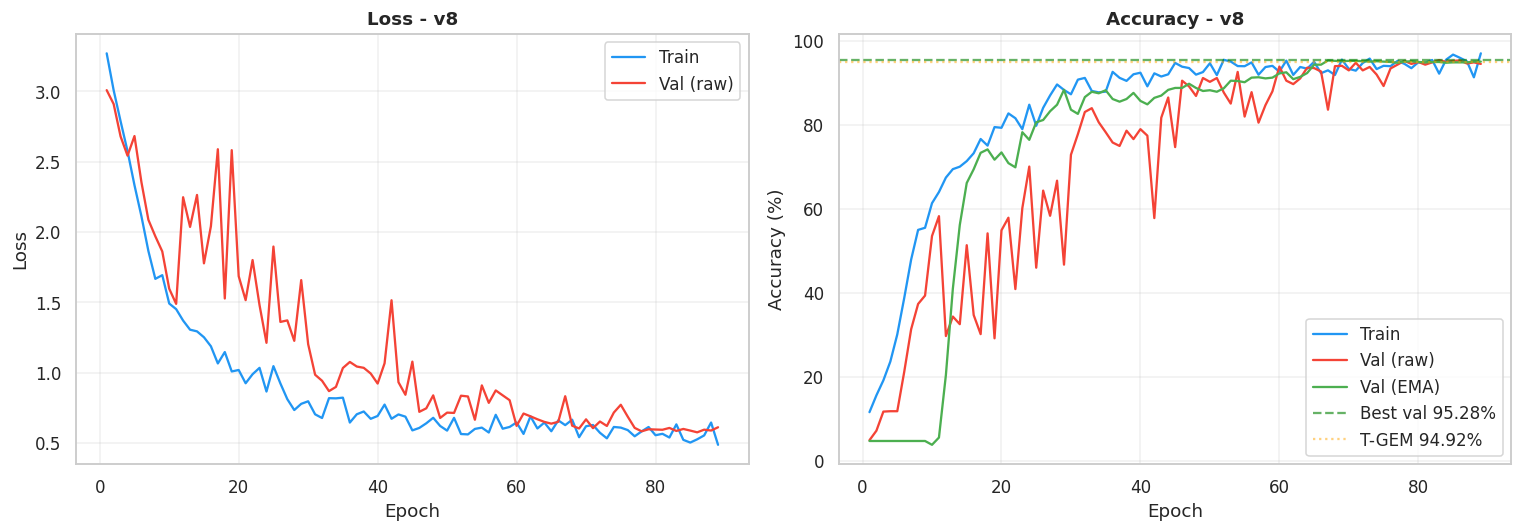

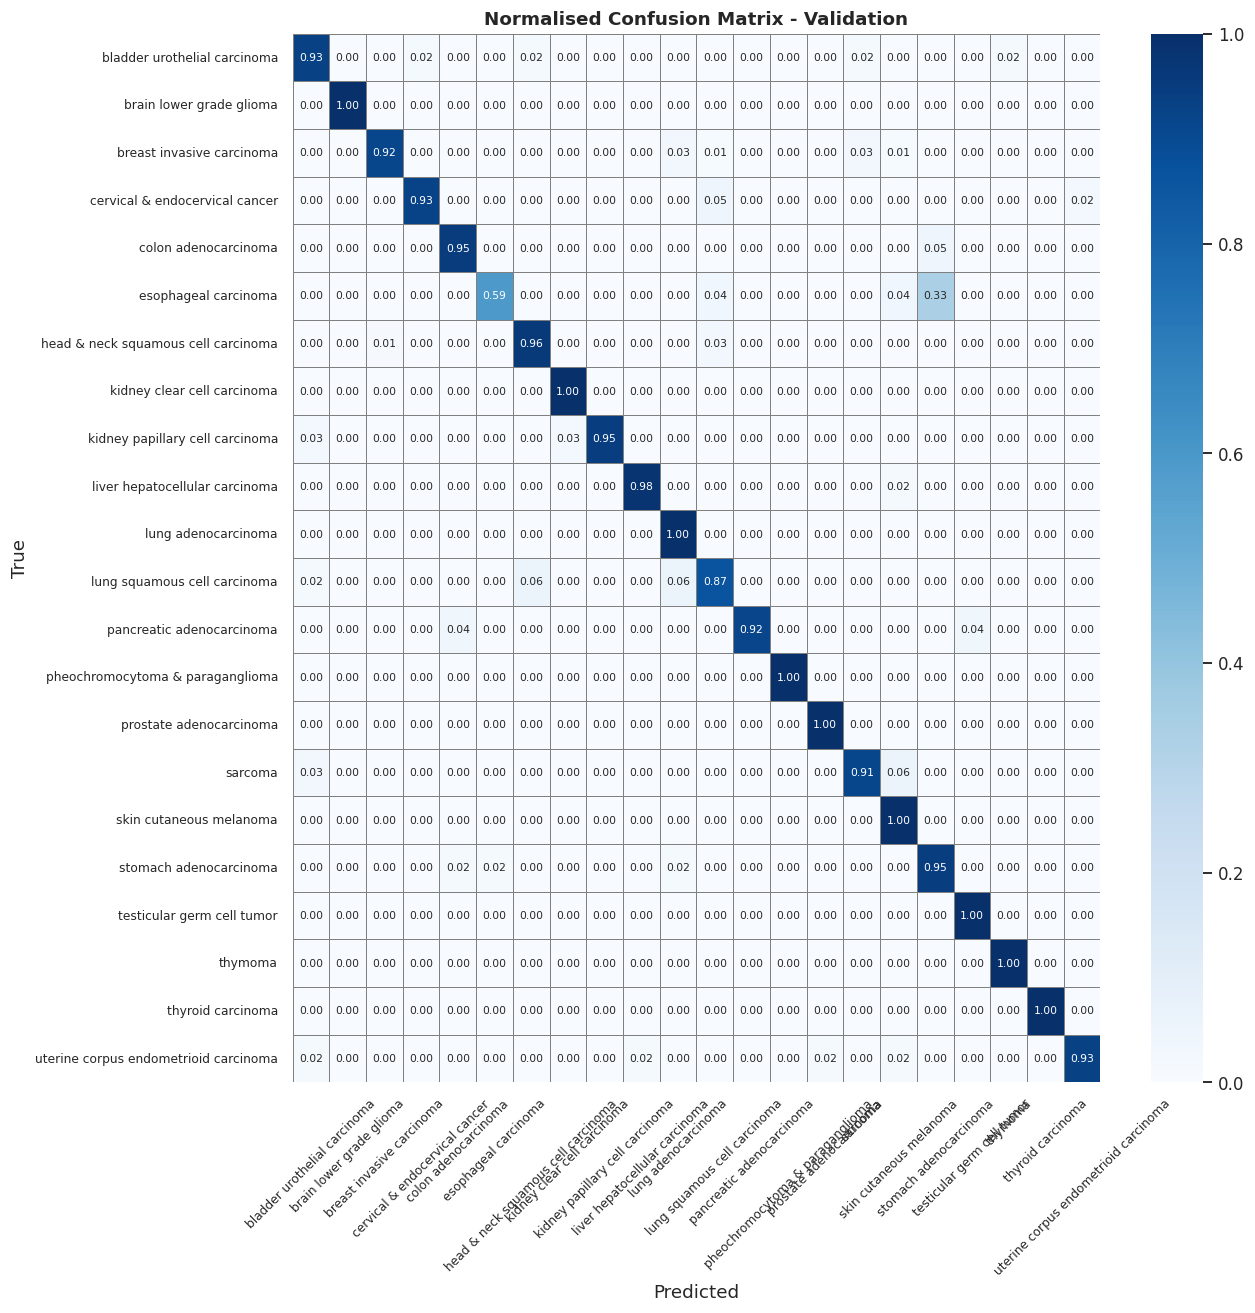

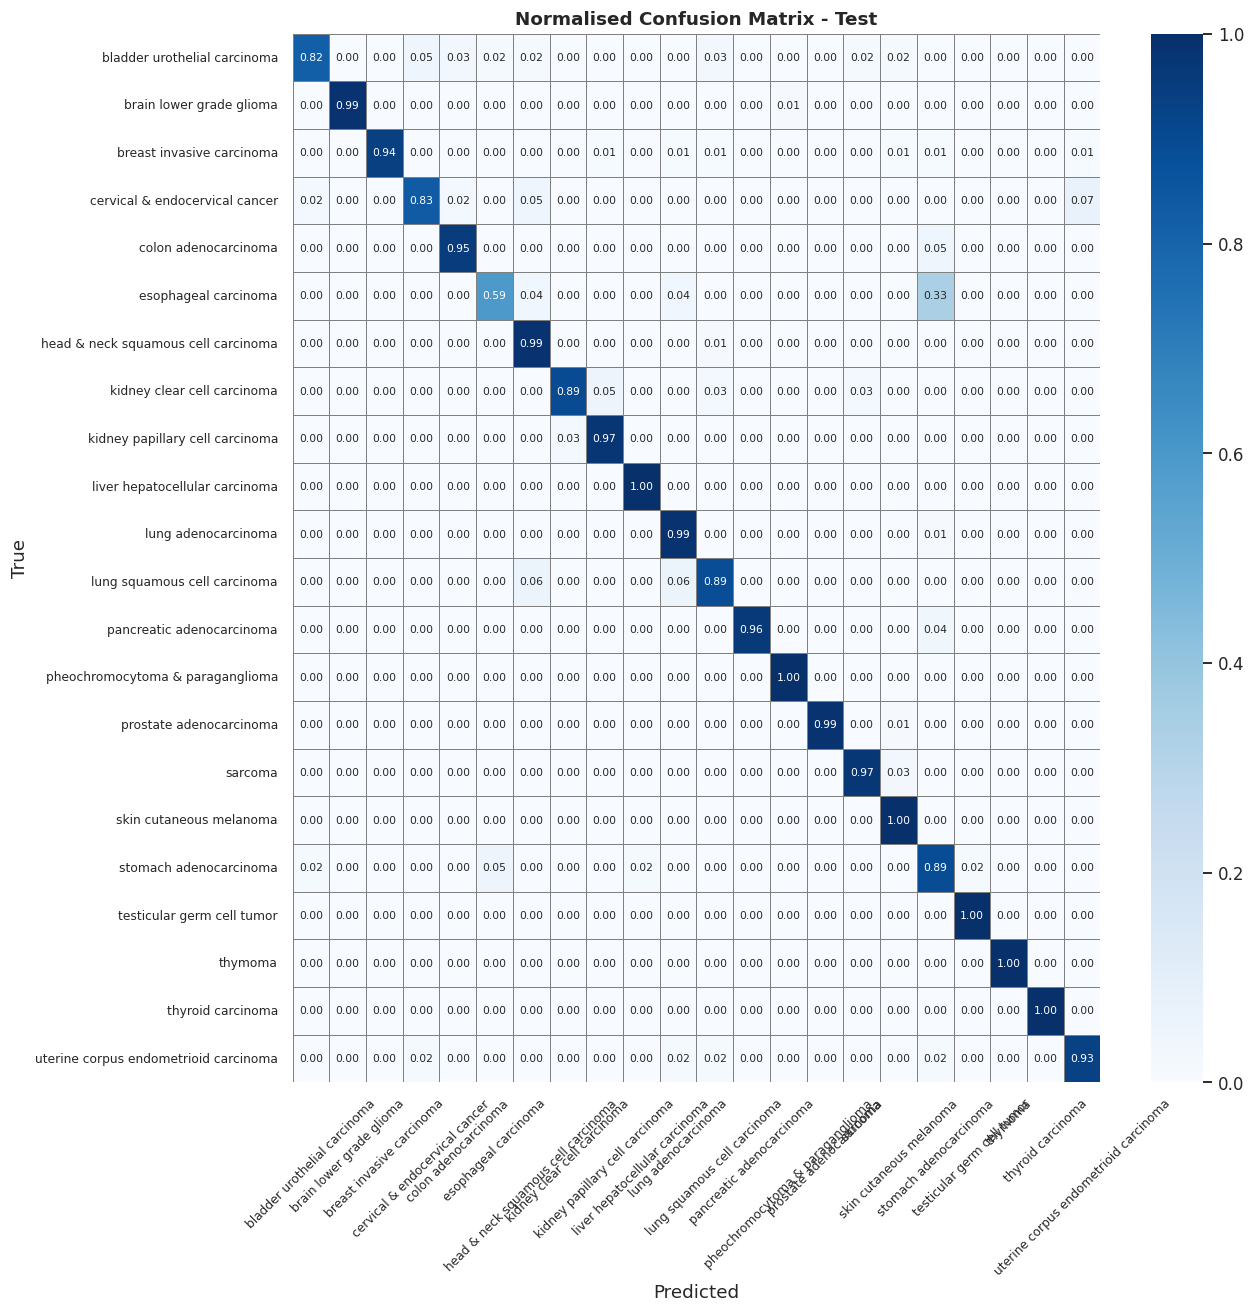

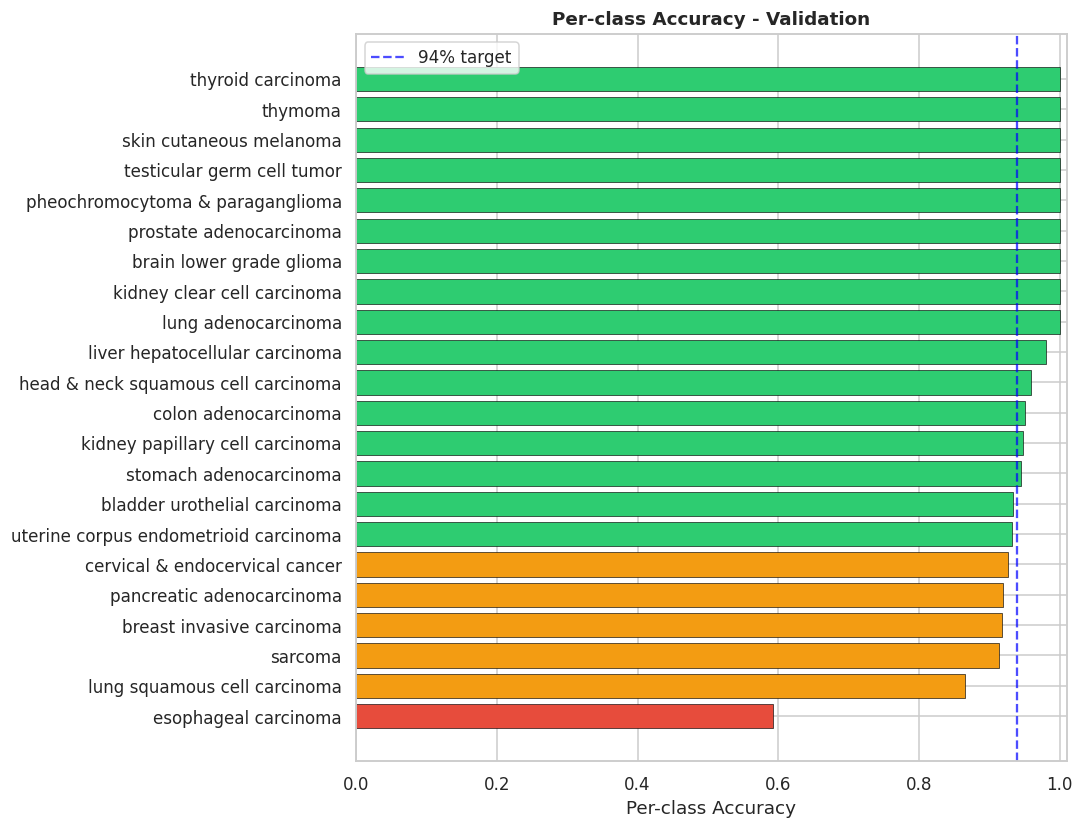

  Classes below 85% on Validation: ['esophageal carcinoma']


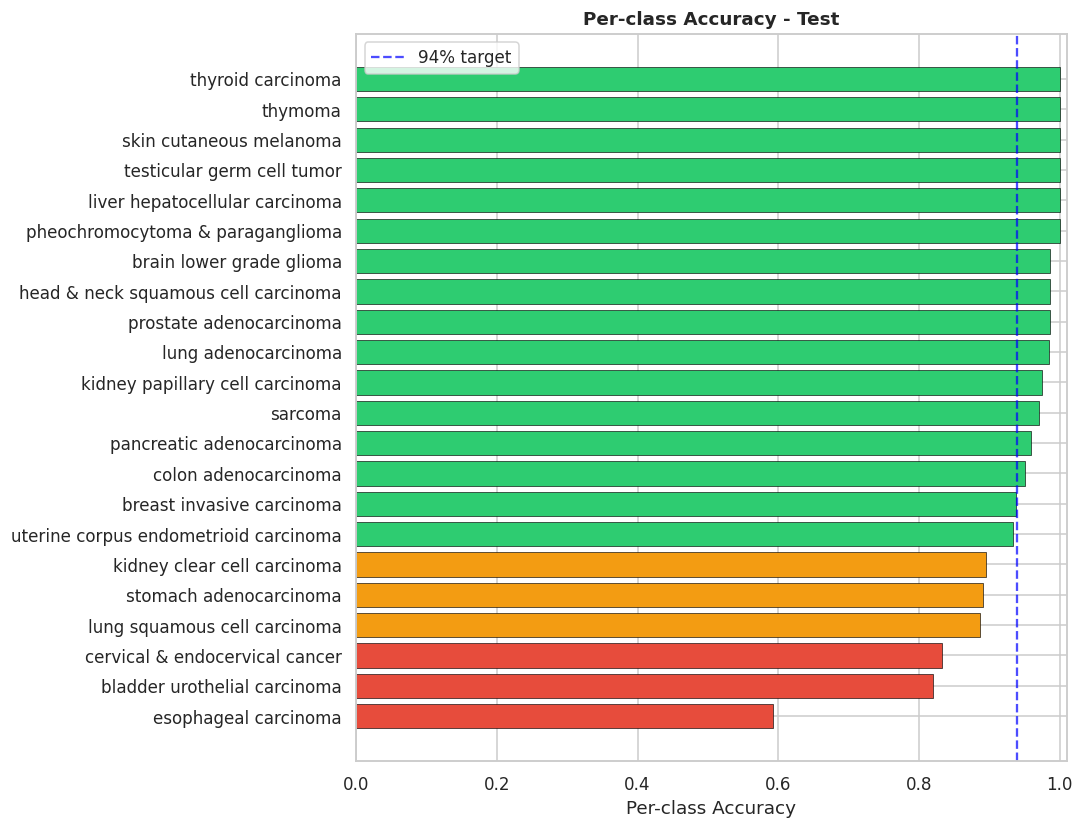

  Classes below 85% on Test: ['bladder urothelial carcinoma', 'cervical & endocervical cancer', 'esophageal carcinoma']

  FINAL RESULTS - OncoBridge-MMCAT v8
  Modalities:     mRNA + CNV + Mutation + Methylation (4-way)
  Gene counts:    {'mrna': 8011, 'cnv': 3500, 'mut': 2500, 'meth': 6000}
  Classes:        22
  Parameters:     86,305,693
  Architecture:   embed=384 | enc=6 | cross=4 | fusion=2 | drop_path=0.1
  Training:       EMA=True | snapshot_top_k=3 | sampler=True
  Inference:      TTA=True (n=5)

  Val Accuracy:   95.19%
  Val Macro F1:   0.9464
  Val MCC:        0.9493
  Test Accuracy:  94.19%
  Test Macro F1:  0.9361
  Test MCC:       0.9388
  Test BalancedAcc: 93.59%


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 13 - Plots: learning curves, confusion matrix, per-class accuracy
# ═══════════════════════════════════════════════════════════════════════════
section('PLOTS')


# ── 1. Learning curves ───────────────────────────────────────────────────
if not CONFIG['LOAD_PRETRAINED'] and len(history.get('train_loss', [])) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    er = range(1, len(history['train_loss']) + 1)

    axes[0].plot(er, history['train_loss'], label='Train',
                 color='#2196F3', linewidth=1.5)
    axes[0].plot(er, history['val_loss'], label='Val (raw)',
                 color='#F44336', linewidth=1.5)
    axes[0].set_title('Loss - v8', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(er, history['train_acc'], label='Train',
                 color='#2196F3', linewidth=1.5)
    axes[1].plot(er, history['val_acc'], label='Val (raw)',
                 color='#F44336', linewidth=1.5)
    if any(v is not None for v in history.get('val_acc_ema', [])):
        axes[1].plot(er, history['val_acc_ema'], label='Val (EMA)',
                     color='#4CAF50', linewidth=1.5)
    axes[1].axhline(best_val_acc, color='green', linestyle='--', alpha=0.6,
                    label=f'Best val {best_val_acc:.2f}%')
    axes[1].axhline(94.92, color='orange', linestyle=':', alpha=0.5,
                    label='T-GEM 94.92%')
    axes[1].set_title('Accuracy - v8', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('learning_curves_v8.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping learning curves (no fresh training history this run).')


# ── 2. Confusion matrix (use TTA preds if available, else plain) ────────
def plot_confusion(name, preds, labels, classes, savepath):
    cm = confusion_matrix(labels, preds, labels=np.arange(len(classes)))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums,
                        out=np.zeros_like(cm, dtype=float),
                        where=row_sums > 0)
    fig, ax = plt.subplots(figsize=(max(12, 0.55 * len(classes)),
                                    max(10, 0.55 * len(classes))))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax,
                linewidths=0.4, linecolor='gray',
                annot_kws={'size': 7})
    ax.set_title(f'Normalised Confusion Matrix - {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.savefig(savepath, dpi=140, bbox_inches='tight')
    plt.show()
    return cm_norm


# Use validation predictions
cm_norm_val = plot_confusion('Validation', final_val_metrics['preds'],
                             val_labels, le.classes_,
                             'confusion_val_v8.png')

if final_test_metrics is not None:
    cm_norm_te = plot_confusion('Test', final_test_metrics['preds'],
                                te_labels, le.classes_,
                                'confusion_test_v8.png')


# ── 3. Per-class accuracy bar chart ─────────────────────────────────────
def plot_per_class(name, cm_norm, classes, savepath):
    per_class_acc = cm_norm.diagonal()
    sorted_idx = np.argsort(per_class_acc)
    fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(classes))))
    colors = ['#e74c3c' if v < 0.85 else '#f39c12' if v < 0.93 else '#2ecc71'
              for v in per_class_acc[sorted_idx]]
    ax.barh([classes[i] for i in sorted_idx], per_class_acc[sorted_idx],
            color=colors, edgecolor='black', linewidth=0.4)
    ax.axvline(0.94, color='blue', linestyle='--', alpha=0.7, label='94% target')
    ax.set_xlabel('Per-class Accuracy')
    ax.set_xlim(0, 1.01)
    ax.set_title(f'Per-class Accuracy - {name}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(savepath, dpi=140, bbox_inches='tight')
    plt.show()
    weak = [classes[i] for i in np.where(per_class_acc < 0.85)[0]]
    print(f'  Classes below 85% on {name}: {weak}')


plot_per_class('Validation', cm_norm_val, le.classes_, 'per_class_val_v8.png')
if final_test_metrics is not None:
    plot_per_class('Test', cm_norm_te, le.classes_, 'per_class_test_v8.png')


# ── 4. Final summary ────────────────────────────────────────────────────
print('\n' + '=' * 78)
print('  FINAL RESULTS - OncoBridge-MMCAT v8')
print('=' * 78)
n_params = sum(p.numel() for p in core_model(model).parameters() if p.requires_grad)
print(f'  Modalities:     mRNA + CNV + Mutation + Methylation (4-way)')
print(f'  Gene counts:    {gene_k}')
print(f'  Classes:        {CONFIG["num_classes"]}')
print(f'  Parameters:     {n_params:,}')
print(f'  Architecture:   embed=384 | enc={CONFIG["num_encoder_layers"]} | '
      f'cross={CONFIG["num_cross_layers"]} | fusion={CONFIG["fusion_layers"]} | '
      f'drop_path={CONFIG["drop_path_max"]}')
print(f'  Training:       EMA={CONFIG["use_ema"]} | snapshot_top_k={CONFIG["snapshot_top_k"]} | '
      f'sampler={CONFIG["use_weighted_sampler"]}')
print(f'  Inference:      TTA={CONFIG["use_tta"]} (n={CONFIG["tta_n_passes"]})')
print()
print(f'  Val Accuracy:   {final_val_metrics["acc"]:.2f}%')
print(f'  Val Macro F1:   {final_val_metrics["mf1"]:.4f}')
print(f'  Val MCC:        {final_val_metrics["mcc"]:.4f}')
if final_test_metrics is not None:
    print(f'  Test Accuracy:  {final_test_metrics["acc"]:.2f}%')
    print(f'  Test Macro F1:  {final_test_metrics["mf1"]:.4f}')
    print(f'  Test MCC:       {final_test_metrics["mcc"]:.4f}')
    print(f'  Test BalancedAcc: {final_test_metrics["bal"]:.2f}%')
print('=' * 78)

## Interpretability: SHAP + Cancer-Gene 2D Atlas

The next two cells produce the interpretability outputs.

### Prerequisites

Both cells need: `model` (loaded), `test_loader`, `gene_indices`, `SELECTED_GENE_NAMES`, `le`, `Xp`, `y`, `te_idx`. **All of these are produced by Cells 1–12**.

### Two ways to run them
1. **After full training** — just *Run All*. By the time you reach Cell 15, everything is in scope.
2. **From a saved checkpoint, no retraining** — set `CONFIG['LOAD_PRETRAINED'] = True` in Cell 2, then run **Cells 1 → 12 in order**, then run Cell 15 (SHAP) and Cell 16 (atlas). Cells 1–12 are fast (~30 s for everything except the first parquet load) because they don't train.

### SHAP cell (Cell 15)
Uses **GradientShap** (the input-gradient based attribution that works well for transformers). For each test sample we get a per-gene importance value per class. We then aggregate to **per-class average gene importance** — this is what the atlas uses.

We deliberately keep the cohort small (`SHAP_PER_CLASS=8`, `SHAP_BG_SIZE=64`) because attribution on a 20k-feature, 82M-param model is heavy. You can dial these up in CONFIG if you have time.

### Cancer-Gene Atlas cell (Cell 16)
Builds a **2D map where every cancer is a labeled point and the genes most responsible for each cancer are placed near it**. Concretely:

1. Compute `embeddings` for every test patient (the fused 384-d vector).
2. Compute `cancer_centroid[c]` = mean embedding for class `c`.
3. From SHAP, per gene `g` we have an importance vector `a[g, c]` (class × class). Only positive importance is kept (genes the model *uses to predict* that class). We then place gene `g` at:

   `gene_pos[g] = sum_c (a[g, c] * cancer_centroid[c]) / sum_c a[g, c]`

   This is a weighted average of the cancer centroids, weighted by how much that gene drives each cancer's prediction. So a TP53-mutation feature important for several cancers ends up at their geometric mean; a thyroid-specific gene ends up sitting on top of the thyroid centroid.

4. Run **UMAP** on `[cancer_centroid_0..C, gene_pos_0..G]` jointly, project to 2D, plot.

Result: a single chart you can put in a paper.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 15 - SHAP analysis (GradientShap on test samples)
#
#  Produces:
#    SHAP_VALUES     : ndarray of shape (n_test_used, n_classes, n_genes_total)
#                      where n_genes_total = sum of selected genes across modalities
#    SHAP_GENE_NAMES : list of length n_genes_total — fully qualified gene IDs
#                      e.g. "mrna::TP53", "meth::TP53"
#    SHAP_LABELS     : ndarray of shape (n_test_used,) — true class indices
#    SHAP_CLASS_IMP  : per-class mean ABS importance, shape (n_classes, n_genes_total)
#    SHAP_CLASS_SIGNED_POS: per-class mean POSITIVE importance,
#                           shape (n_classes, n_genes_total) — used by the atlas
#
#  Notes
#  - We use captum.attr.GradientShap, falling back to a manual integrated-grad
#    style estimator if captum is not installed.
#  - Attribution is computed per (input, target_class). We use the *true*
#    label as the target so the atlas reflects what the model uses to
#    correctly classify each cancer.
#  - The model is wrapped to take a single concatenated input of shape
#    (B, n_genes_total). We split internally back into the 4 modalities.
# ═══════════════════════════════════════════════════════════════════════════
section('SHAP ANALYSIS')

if not CONFIG['RUN_SHAP']:
    print('RUN_SHAP=False -> skipping SHAP cell.')
else:
    import importlib

    # Try to import captum; install instructions if not present
    try:
        from captum.attr import GradientShap
        _have_captum = True
    except Exception as e:
        print('captum not installed. Install it with:')
        print('   !pip install captum --quiet')
        print('Then re-run this cell.')
        _have_captum = False

    if _have_captum:
        # ── 1. Build the concatenated wrapper ──────────────────────────────
        sizes = [
            Xp['mrna']['te'].shape[1],
            Xp['cnv']['te'].shape[1],
            Xp['mut']['te'].shape[1],
            Xp['meth']['te'].shape[1],
        ]
        offsets = [0]
        for s in sizes: offsets.append(offsets[-1] + s)
        n_genes_total = offsets[-1]
        print(f'Total concatenated feature dim: {n_genes_total}')
        print(f'Modality sizes: mRNA={sizes[0]} CNV={sizes[1]} Mut={sizes[2]} Meth={sizes[3]}')

        class ConcatWrapper(nn.Module):
            def __init__(self, base, offsets):
                super().__init__()
                self.base = base
                self.offsets = offsets
            def forward(self, x):
                # x : (B, n_genes_total)
                o = self.offsets
                m  = x[:, o[0]:o[1]]
                c  = x[:, o[1]:o[2]]
                u  = x[:, o[2]:o[3]]
                e  = x[:, o[3]:o[4]]
                return self.base(m, c, u, e)

        wrapped = ConcatWrapper(core_model(model), offsets).to(DEVICE)
        wrapped.eval()

        # ── 2. Build full test-set tensor (concatenated) ────────────────
        X_te_concat = np.concatenate([
            Xp['mrna']['te'], Xp['cnv']['te'], Xp['mut']['te'], Xp['meth']['te']
        ], axis=1).astype(np.float32)
        y_te = y[te_idx]
        print(f'Test set: {X_te_concat.shape[0]} samples x {X_te_concat.shape[1]} features')

        # ── 3. Background + target sample selection ────────────────────
        # Background = stratified random subset of TRAINING samples (used as
        # 'baseline distribution' by GradientShap)
        rng = np.random.default_rng(CONFIG['seed'])
        n_bg = min(CONFIG['SHAP_BG_SIZE'], len(tr_idx))
        bg_pos = rng.choice(len(tr_idx), n_bg, replace=False)
        X_bg_concat = np.concatenate([
            Xp['mrna']['tr'][bg_pos], Xp['cnv']['tr'][bg_pos],
            Xp['mut']['tr'][bg_pos],  Xp['meth']['tr'][bg_pos]
        ], axis=1).astype(np.float32)
        baseline = torch.from_numpy(X_bg_concat).to(DEVICE)
        print(f'Background size: {baseline.shape[0]}')

        # Target samples: SHAP_PER_CLASS test samples per class
        per_cls = CONFIG['SHAP_PER_CLASS']
        sel_pos = []
        for c in range(CONFIG['num_classes']):
            pos_c = np.where(y_te == c)[0]
            if len(pos_c) == 0:
                continue
            take = min(per_cls, len(pos_c))
            chosen = rng.choice(pos_c, take, replace=False)
            sel_pos.extend(chosen.tolist())
        sel_pos = np.array(sel_pos)
        print(f'Selected {len(sel_pos)} test samples for SHAP '
              f'(<={per_cls} per class).')

        X_target = torch.from_numpy(X_te_concat[sel_pos]).to(DEVICE)
        y_target = torch.from_numpy(y_te[sel_pos]).to(DEVICE)

        # ── 4. Run GradientShap one sample at a time (manageable memory) ──
        gs = GradientShap(wrapped)
        SHAP_VALUES = np.zeros((len(sel_pos), n_genes_total), dtype=np.float32)

        # We attribute against the TRUE class. (Targeting predicted class is
        # also reasonable; using true class produces a cleaner per-class map.)
        print('Computing attributions...')
        # Run in micro-batches for VRAM safety
        MICRO = 4
        with Timer('GradientShap'):
            for start in range(0, len(sel_pos), MICRO):
                end = min(start + MICRO, len(sel_pos))
                xb = X_target[start:end]
                yb = y_target[start:end]
                # GradientShap: n_samples is the # of stochastic noise samples,
                # not # of background examples (it draws baselines uniformly
                # from `baselines`). 8 is a reasonable speed/quality trade.
                attr = gs.attribute(
                    xb,
                    baselines=baseline,
                    target=yb,
                    n_samples=8,
                    stdevs=0.05,
                )
                SHAP_VALUES[start:end] = attr.detach().cpu().float().numpy()
                if (start // MICRO) % 5 == 0:
                    print(f'  attributed {end}/{len(sel_pos)}')

        SHAP_LABELS = y_te[sel_pos]

        # ── 5. Build feature names ─────────────────────────────────────
        SHAP_GENE_NAMES = (
              [f'mrna::{g}' for g in SELECTED_GENE_NAMES['mrna']]
            + [f'cnv::{g}'  for g in SELECTED_GENE_NAMES['cnv']]
            + [f'mut::{g}'  for g in SELECTED_GENE_NAMES['mut']]
            + [f'meth::{g}' for g in SELECTED_GENE_NAMES['meth']]
        )
        assert len(SHAP_GENE_NAMES) == n_genes_total

        # ── 6. Per-class aggregations ──────────────────────────────────
        SHAP_CLASS_IMP_ABS    = np.zeros((CONFIG['num_classes'], n_genes_total),
                                          dtype=np.float32)
        SHAP_CLASS_SIGNED_POS = np.zeros((CONFIG['num_classes'], n_genes_total),
                                          dtype=np.float32)
        for c in range(CONFIG['num_classes']):
            mask = (SHAP_LABELS == c)
            if mask.sum() == 0:
                continue
            arr = SHAP_VALUES[mask]
            SHAP_CLASS_IMP_ABS[c]   = np.abs(arr).mean(axis=0)
            SHAP_CLASS_SIGNED_POS[c] = np.clip(arr, 0, None).mean(axis=0)

        print(f'\nSHAP per-class aggregates: shape={SHAP_CLASS_IMP_ABS.shape}')

        # ── 7. Plot top-K most important genes per class (heatmap) ──────
        TOP_PER_CLASS = 8
        top_gene_idx = set()
        for c in range(CONFIG['num_classes']):
            top_local = np.argsort(SHAP_CLASS_IMP_ABS[c])[::-1][:TOP_PER_CLASS]
            for g in top_local:
                top_gene_idx.add(int(g))
        top_gene_idx = np.array(sorted(top_gene_idx))
        print(f'Union of top-{TOP_PER_CLASS} genes per class: {len(top_gene_idx)} genes')

        heat = SHAP_CLASS_IMP_ABS[:, top_gene_idx]
        # Min-max normalise per class for readable colors
        heat_n = heat.copy()
        for r in range(heat.shape[0]):
            mx = heat_n[r].max() if heat_n[r].max() > 0 else 1.0
            heat_n[r] = heat_n[r] / mx

        fig, ax = plt.subplots(figsize=(min(28, max(12, 0.18 * len(top_gene_idx))),
                                         max(8, 0.35 * CONFIG['num_classes'])))
        sns.heatmap(heat_n,
                    yticklabels=le.classes_,
                    xticklabels=[SHAP_GENE_NAMES[i] for i in top_gene_idx],
                    cmap='viridis', cbar_kws={'label': 'Per-class normalised |SHAP|'},
                    ax=ax)
        ax.set_title(f'Top-{TOP_PER_CLASS} SHAP-important features per cancer (union)',
                     fontweight='bold')
        ax.tick_params(axis='x', rotation=90, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=8)
        plt.tight_layout()
        plt.savefig('shap_heatmap_v8.png', dpi=140, bbox_inches='tight')
        plt.show()

        # ── 8. Top-N table per class (printed) ──────────────────────────
        N = 5
        print('\nTop-5 SHAP-important features per cancer class:')
        for c in range(CONFIG['num_classes']):
            top_local = np.argsort(SHAP_CLASS_IMP_ABS[c])[::-1][:N]
            names = [SHAP_GENE_NAMES[i] for i in top_local]
            vals  = [f'{SHAP_CLASS_IMP_ABS[c, i]:.4f}' for i in top_local]
            pairs = ', '.join(f'{n}({v})' for n, v in zip(names, vals))
            print(f'  {le.classes_[c]:<45} {pairs}')

        # ── 9. Persist for the atlas cell ───────────────────────────────
        np.savez_compressed(
            '/kaggle/working/shap_results_v8.npz',
            SHAP_VALUES=SHAP_VALUES,
            SHAP_LABELS=SHAP_LABELS,
            SHAP_CLASS_IMP_ABS=SHAP_CLASS_IMP_ABS,
            SHAP_CLASS_SIGNED_POS=SHAP_CLASS_SIGNED_POS,
            sel_pos=sel_pos,
        )
        with open('/kaggle/working/shap_gene_names_v8.json', 'w') as f:
            json.dump(SHAP_GENE_NAMES, f)
        print('\nSaved SHAP results -> /kaggle/working/shap_results_v8.npz')


  SHAP ANALYSIS
RUN_SHAP=False -> skipping SHAP cell.


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 16 - Cancer-Gene 2D Atlas
#
#  Builds a 2D map where every cancer is a labeled point, and the genes most
#  responsible for each cancer's prediction are placed near it.
#
#  Steps:
#    1. Compute fused embeddings for every test patient (the 384-d 'fused'
#       vector returned by the FusionTransformer).
#    2. Per class, take the centroid of those embeddings -> cancer anchor.
#    3. For each gene g (across all 4 modalities), use SHAP per-class POSITIVE
#       importance to compute a 384-d gene embedding:
#           gene_emb[g] = sum_c (a_pos[g,c] * cancer_centroid[c])
#                        / sum_c a_pos[g,c]
#       i.e. weighted average of cancer centroids by how much g drives c.
#    4. Stack [cancer_centroids ; gene_embs] and run UMAP -> 2D.
#    5. Plot cancers as labeled markers; show top-K genes per cancer near it.
# ═══════════════════════════════════════════════════════════════════════════
section('CANCER-GENE 2D ATLAS')

if not CONFIG['RUN_ATLAS']:
    print('RUN_ATLAS=False -> skipping atlas cell.')
elif test_loader is None:
    print('No test loader -> cannot build atlas.')
else:
    # ── Load SHAP results from disk if not in memory ────────────────────
    have_in_memory = 'SHAP_CLASS_SIGNED_POS' in dir()
    if not have_in_memory:
        try:
            shap_npz = np.load('/kaggle/working/shap_results_v8.npz')
            SHAP_CLASS_SIGNED_POS = shap_npz['SHAP_CLASS_SIGNED_POS']
            SHAP_CLASS_IMP_ABS    = shap_npz['SHAP_CLASS_IMP_ABS']
            with open('/kaggle/working/shap_gene_names_v8.json') as f:
                SHAP_GENE_NAMES = json.load(f)
            print('Loaded SHAP results from disk.')
        except FileNotFoundError:
            raise RuntimeError(
                'SHAP results not in memory and not on disk. '
                'Run Cell 15 (SHAP) first.')

    n_genes_total = SHAP_CLASS_SIGNED_POS.shape[1]
    n_classes     = SHAP_CLASS_SIGNED_POS.shape[0]

    # ── 1. Compute fused embeddings for test set ────────────────────────
    print('Extracting fused embeddings on test set...')

    @torch.no_grad()
    def extract_fused(model, loader):
        model.eval()
        all_emb, all_lab = [], []
        for mrna, cnv, mut, meth, labels in loader:
            mrna = mrna.to(DEVICE, non_blocking=True)
            cnv  = cnv.to(DEVICE,  non_blocking=True)
            mut  = mut.to(DEVICE,  non_blocking=True)
            meth = meth.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                # Use the underlying model so we can request features.
                _, fused, _ = core_model(model)(
                    mrna, cnv, mut, meth, return_features=True)
            all_emb.append(fused.float().cpu().numpy())
            all_lab.append(labels.numpy())
        return np.concatenate(all_emb), np.concatenate(all_lab)

    emb_te, lab_te = extract_fused(model, test_loader)
    print(f'  test embeddings shape: {emb_te.shape}')

    # ── 2. Per-class centroid ────────────────────────────────────────────
    E = emb_te.shape[1]
    cancer_centroids = np.zeros((n_classes, E), dtype=np.float32)
    for c in range(n_classes):
        mask = (lab_te == c)
        if mask.sum() == 0:
            # No test samples of this class — use overall mean as fallback
            cancer_centroids[c] = emb_te.mean(axis=0)
        else:
            cancer_centroids[c] = emb_te[mask].mean(axis=0)

    # ── 3. Gene embeddings as weighted averages of class centroids ──────
    # SHAP_CLASS_SIGNED_POS: (C, G); higher = gene drives that class up.
    A = SHAP_CLASS_SIGNED_POS.astype(np.float32)             # (C, G)
    # Add small floor so genes that are zero everywhere get neutral position
    eps = 1e-9
    Wg = A.T                                                 # (G, C)
    row_sums = Wg.sum(axis=1, keepdims=True) + eps           # (G, 1)
    Wg_norm = Wg / row_sums                                  # (G, C)
    gene_embs = Wg_norm @ cancer_centroids                   # (G, E)

    # Filter out genes whose total positive importance is negligible
    # (they would just sit at the global mean, cluttering the plot)
    gene_total_imp = SHAP_CLASS_IMP_ABS.sum(axis=0)          # (G,)
    keep_mask = gene_total_imp > np.quantile(gene_total_imp, 0.85)
    keep_idx = np.where(keep_mask)[0]
    print(f'  Retained {len(keep_idx)} of {n_genes_total} genes for plotting '
          f'(top 15% by SHAP impact).')

    # ── 4. UMAP joint projection ────────────────────────────────────────
    try:
        import umap
        _have_umap = True
    except Exception:
        print('umap-learn not installed. Falling back to PCA.')
        print('   Install with: !pip install umap-learn --quiet')
        _have_umap = False

    stacked = np.vstack([cancer_centroids, gene_embs[keep_idx]])
    print(f'  Joint stack for projection: {stacked.shape}')

    if _have_umap:
        reducer = umap.UMAP(
            n_neighbors=15,
            min_dist=0.25,
            n_components=2,
            metric='cosine',
            random_state=CONFIG['seed'],
        )
        proj = reducer.fit_transform(stacked)
    else:
        from sklearn.decomposition import PCA
        proj = PCA(n_components=2, random_state=CONFIG['seed']).fit_transform(stacked)

    cancer_proj = proj[:n_classes]
    gene_proj   = proj[n_classes:]

    # ── 5. Pick top-K genes per cancer to label ─────────────────────────
    K_LABEL = 5
    label_records = []   # (gene_idx_in_keep, cancer_c)
    seen = set()
    for c in range(n_classes):
        # Use abs-importance for "most important", positive importance for direction
        order = np.argsort(SHAP_CLASS_IMP_ABS[c, keep_idx])[::-1]
        chosen = []
        for j in order:
            if j in seen:
                continue
            chosen.append(j)
            seen.add(j)
            if len(chosen) >= K_LABEL:
                break
        for j in chosen:
            label_records.append((int(j), c))

    print(f'  Labeling {len(label_records)} gene markers in total.')

    # ── 6. Plot the atlas ───────────────────────────────────────────────
    plt.figure(figsize=(16, 13))

    # Color per class
    palette = sns.color_palette('hls', n_classes)

    # Genes: light grey dots (all retained)
    plt.scatter(gene_proj[:, 0], gene_proj[:, 1],
                s=12, color='lightgray', alpha=0.45, edgecolor='none',
                label='gene (top SHAP)')

    # Highlight labeled genes (one color per their owning class) and add text
    for j, c in label_records:
        plt.scatter(gene_proj[j, 0], gene_proj[j, 1],
                    s=22, color=palette[c], alpha=0.85, edgecolor='black',
                    linewidth=0.3)
        plt.text(gene_proj[j, 0], gene_proj[j, 1] + 0.05,
                 SHAP_GENE_NAMES[keep_idx[j]],
                 fontsize=6, color=palette[c], alpha=0.9, ha='center')

    # Cancer centroids: large markers + label
    for c in range(n_classes):
        plt.scatter(cancer_proj[c, 0], cancer_proj[c, 1],
                    s=260, color=palette[c], edgecolor='black', linewidth=1.2,
                    zorder=5)
        plt.text(cancer_proj[c, 0], cancer_proj[c, 1] - 0.15,
                 le.classes_[c],
                 fontsize=8.5, fontweight='bold', ha='center',
                 zorder=6,
                 bbox=dict(facecolor='white', alpha=0.6,
                           edgecolor='none', pad=1.5))

    plt.title('Cancer-Gene 2D Atlas\n'
              f'(cancer centroids + top-{K_LABEL} SHAP genes per cancer; '
              f'{"UMAP" if _have_umap else "PCA"} on fused embeddings)',
              fontweight='bold', fontsize=13)
    plt.xlabel('component 1'); plt.ylabel('component 2')
    plt.tight_layout()
    plt.savefig('cancer_gene_atlas_v8.png', dpi=170, bbox_inches='tight')
    plt.show()

    print('\nAtlas saved -> cancer_gene_atlas_v8.png')

    # ── 7. Also plot a clean "patients-only" UMAP for comparison ────────
    print('\nAlso plotting plain test-patient UMAP for sanity...')
    if _have_umap:
        reducer2 = umap.UMAP(n_neighbors=20, min_dist=0.15, n_components=2,
                             metric='cosine', random_state=CONFIG['seed'])
        pat_proj = reducer2.fit_transform(emb_te)
    else:
        from sklearn.decomposition import PCA
        pat_proj = PCA(n_components=2,
                       random_state=CONFIG['seed']).fit_transform(emb_te)

    plt.figure(figsize=(13, 11))
    for c in range(n_classes):
        mask = (lab_te == c)
        if mask.sum() == 0: continue
        plt.scatter(pat_proj[mask, 0], pat_proj[mask, 1],
                    s=22, color=palette[c], alpha=0.65, edgecolor='none',
                    label=le.classes_[c])
    plt.title('Test-set patient embeddings (fused 384-d -> 2D)',
              fontweight='bold')
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left',
               fontsize=7, ncol=1, frameon=False)
    plt.tight_layout()
    plt.savefig('patient_embedding_umap_v8.png', dpi=160, bbox_inches='tight')
    plt.show()
    print('Patient UMAP saved -> patient_embedding_umap_v8.png')


  CANCER-GENE 2D ATLAS
RUN_ATLAS=False -> skipping atlas cell.


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
#  Cell 17 - Final summary and saved artifacts
# ═══════════════════════════════════════════════════════════════════════════
section('FINAL SUMMARY')

print('Saved artifacts:')
artifacts = [
    ('learning_curves_v8.png',     'Learning curves'),
    ('confusion_val_v8.png',       'Validation confusion matrix'),
    ('confusion_test_v8.png',      'Test confusion matrix'),
    ('per_class_val_v8.png',       'Validation per-class accuracy'),
    ('per_class_test_v8.png',      'Test per-class accuracy'),
    ('shap_heatmap_v8.png',        'SHAP per-class heatmap'),
    ('cancer_gene_atlas_v8.png',   'Cancer-Gene 2D Atlas'),
    ('patient_embedding_umap_v8.png','Test patient UMAP'),
    (CONFIG['CHECKPOINT_PATH'],     'Full reproducible checkpoint (.pt)'),
    ('/kaggle/working/shap_results_v8.npz', 'SHAP values + per-class aggregates'),
    ('/kaggle/working/shap_gene_names_v8.json','Gene names matched to SHAP columns'),
]
for path, desc in artifacts:
    exists = '+' if os.path.exists(path) else '-'
    print(f'  [{exists}] {path:<50} {desc}')

print()
print('Benchmark comparison:')
print('-' * 78)
print(f'  {"Model":<30} {"Acc":<10} {"Classes":<8} {"Modalities":<11} {"Notes"}')
print('-' * 78)
print(f'  OncoBridge v3                  91.94%     22       3           best 3-modality v3')
print(f'  OncoBridge v7 (22-class)       95.74%     22       4           4-mod, prior best')
print(f'  OncoBridge v7 (32-class)       91.24%     32       4           all classes')
print(f'  T-GEM                          94.92%     33       1 (mRNA)    10,340 samples')
test_acc_str = (f'{final_test_metrics["acc"]:.2f}%'
                if final_test_metrics is not None else 'N/A')
print(f'  >>> OncoBridge v8 (this run)   {test_acc_str:<10} {CONFIG["num_classes"]:<8} '
      f'4           NEW: EMA+TTA+SnapAvg+SHAP')
print('-' * 78)

print()
print('How to run analysis cells (15, 16) without retraining:')
print('  1. Set CONFIG["LOAD_PRETRAINED"] = True in Cell 2')
print('  2. Run Cells 1 -> 12 in order (data setup is fast).')
print('  3. Run Cell 15 (SHAP) and Cell 16 (Atlas).')
print()
print('Done.')


  FINAL SUMMARY
Saved artifacts:
  [+] learning_curves_v8.png                             Learning curves
  [+] confusion_val_v8.png                               Validation confusion matrix
  [+] confusion_test_v8.png                              Test confusion matrix
  [+] per_class_val_v8.png                               Validation per-class accuracy
  [+] per_class_test_v8.png                              Test per-class accuracy
  [-] shap_heatmap_v8.png                                SHAP per-class heatmap
  [-] cancer_gene_atlas_v8.png                           Cancer-Gene 2D Atlas
  [-] patient_embedding_umap_v8.png                      Test patient UMAP
  [+] /kaggle/working/oncobridge_v8_full.pt              Full reproducible checkpoint (.pt)
  [-] /kaggle/working/shap_results_v8.npz                SHAP values + per-class aggregates
  [-] /kaggle/working/shap_gene_names_v8.json            Gene names matched to SHAP columns

Benchmark comparison:
-----------------------------